# Some Current Analysis

1. Task Accuracy/ Concept Accuracy - even though I made the graph much noiser its stable but from the result of learned graph at 0.5 soft threshold I see many FP and FN
2. cci is high means cocnepts is still contributinhg
3. Leakage almost 0 everywhere so good
4. PPF = 0.75 FOR CFMINST GOOD

## Issue : Learn Graph and and its weight
The learned graph are very noisy 
as f1 score is too low, yes precision is high
- My graph learning rate is low could be due to that

 prior_weight: 0.1  this is not allowing the graph to deviate and learn problaly make it much lower to learn aside from initial vote, sparsity_weight: 0.01

 - For soft DAG we should find on and off instead of avg towrds 0 or 1 

- Single LR for network and graph so bascially gradient is coming from all the way from end to back edg (Adam) , hence they barely move (graph weight)

- Freeeze the graph learning for first 5 epoch then resume for better signal of weights - instead of directly starts form noise


No graph learning is actaully happening as task loss and concpets loss is actually not much from start
no gradient signal hence no edge or graph improve

- Test cream on high noisy graph - soft > 0.5 to make it (GRAPH MATTERS OR NOT?)
- Rival 10 , Animal

Different network for graph - Network behind network, combine prediction results instead pertubating it (Each graph as a network )

In [1]:
def parse_exp_name(exp_name: str):
    sorted_methods = sorted(METHODS, key=len, reverse=True)
    method = None
    remainder = exp_name
    for m in sorted_methods:
        if exp_name == m or exp_name.startswith(m + "_"):
            method = m
            remainder = exp_name[len(m):].lstrip("_")
            break
    if method is None:
        parts = exp_name.split("_")
        method = parts[0]
        remainder = "_".join(parts[1:])
    parts = remainder.split("_")
    m_val = None
    level = None
    for i, p in enumerate(parts):
        if p.startswith("M") and p[1:].isdigit():
            m_val = int(p[1:])
            level = "_".join(parts[i + 1:])
            break
    return method, m_val, level

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# ─── CONFIGURE PATHS ─────────────────────────────────────────────────────────
# Change this to your server-mounted path or local copy
EXPERIMENTS_ROOT = Path(r"/home/dani00003/mCREAM/experiments")  # or Path("/home/dani00003/mCREAM/experiments")

DATASETS = ["CelebA", "Complete_Concept_FMNIST"]
METHODS = ["edge", "graph", "graph_mlp"]
M_VALUES = [5, 10]
DISAGREEMENT_LEVELS = ["low", "medium", "high",]

print(f"Looking for results in: {EXPERIMENTS_ROOT.resolve()}")
print(f"Exists: {EXPERIMENTS_ROOT.exists()}")

Looking for results in: /home/dani00003/mCREAM/experiments
Exists: True


## 1. Load All Results CSVs

In [3]:
def load_all_results(root: Path) -> pd.DataFrame:
    """Scan experiment directories and load all per-seed result CSVs."""
    all_rows = []
    
    for dataset in DATASETS:
        mcream_dir = root / dataset / "train_cbm" / "mCREAM"
        if not mcream_dir.exists():
            print(f"  [SKIP] {mcream_dir} not found")
            continue
        
        for exp_dir in sorted(mcream_dir.iterdir()):
            if not exp_dir.is_dir():
                continue
            exp_name = exp_dir.name  # e.g., edge_M5_medium
            
            # Parse experiment name
            method, m_val, level = parse_exp_name(exp_name)
            
            # Look for per-seed results
            for seed_dir in sorted(exp_dir.iterdir()):
                if not seed_dir.is_dir() or not seed_dir.name.startswith("seed_"):
                    continue
                seed = int(seed_dir.name.split("_")[1])
                
                # Find the CSV inside lightning_logs/version_X/
                for version_dir in sorted(seed_dir.glob("lightning_logs/version_*")):
                    csv_files = list(version_dir.glob("*.csv"))
                    # Main results CSV (not intervention_results)
                    main_csvs = [f for f in csv_files 
                                 if f.name != "intervention_results.csv"
                                 and "perc_" not in f.name
                                 and "seed" not in f.name]
                    if main_csvs:
                        for csv_f in main_csvs:
                            if method in METHODS:
                                try:
                                    df = pd.read_csv(csv_f)
                                    df["dataset"] = dataset
                                    df["method"] = method
                                    df["M"] = m_val
                                    df["disagreement_level"] = level
                                    df["seed"] = seed
                                    df["experiment_name"] = exp_name
                                    df["source_file"] = str(csv_f)
                                    all_rows.append(df)
                                except Exception as e:
                                    print(f"    [ERR] {csv_f}: {e}")
    
    if not all_rows:
        print("No results found!")
        return pd.DataFrame()
    
    results = pd.concat(all_rows, ignore_index=True)
    print(f"\nLoaded {len(results)} result rows from {len(all_rows)} files")
    return results

results_df = load_all_results(EXPERIMENTS_ROOT)
if len(results_df) > 0:
    print(f"\nDatasets: {results_df['dataset'].unique()}")
    print(f"Methods: {results_df['method'].unique()}")
    print(f"M values: {results_df['M'].unique()}")
    print(f"Levels: {results_df['disagreement_level'].unique()}")
    results_df.head()


Loaded 241 result rows from 241 files

Datasets: ['CelebA' 'Complete_Concept_FMNIST']
Methods: ['edge' 'graph' 'graph_mlp']
M values: [10  5]
Levels: ['high' 'low' 'medium' 'structured_bias']


## 2. Load Intervention Results

In [4]:
def load_all_interventions(root: Path) -> pd.DataFrame:
    """Load all intervention_results.csv files."""
    all_rows = []
    
    for dataset in DATASETS:
        mcream_dir = root / dataset / "train_cbm" / "mCREAM"
        if not mcream_dir.exists():
            continue
        
        for csv_f in mcream_dir.rglob("intervention_results.csv"):
            try:
                df = pd.read_csv(csv_f)
                # Extract metadata from path
                # .../mCREAM/edge_M5_medium/seed_42/lightning_logs/version_0/intervention_results.csv
                parts = csv_f.parts
                exp_name = None
                seed = None
                for i, p in enumerate(parts):
                    if p == "mCREAM" and i + 1 < len(parts):
                        exp_name = parts[i + 1]
                    if p.startswith("seed_"):
                        seed = int(p.split("_")[1])
                
                if exp_name:
                    method, m_val, level = parse_exp_name(exp_name)
                    
                    df["dataset"] = dataset
                    df["method"] = method
                    df["M"] = m_val
                    df["disagreement_level"] = level
                    df["seed"] = seed
                    df["experiment_name"] = exp_name
                    all_rows.append(df)
            except Exception as e:
                print(f"  [ERR] {csv_f}: {e}")
    
    if not all_rows:
        return pd.DataFrame()
    
    interventions_df = pd.concat(all_rows, ignore_index=True)
    print(f"Loaded {len(interventions_df)} intervention rows")
    return interventions_df

interventions_df = load_all_interventions(EXPERIMENTS_ROOT)
if len(interventions_df) > 0:
    print(interventions_df.head())

Loaded 3868 intervention rows
     mode  num_interventions  test_task_accuracy  test_concept_accuracy  \
0  simple                  0            0.772468               0.797258   
1  simple                  1            0.838844               0.843997   
2  simple                  2            0.838844               0.858925   
3  simple                  3            0.838794               0.873724   
4  simple                  4            0.838794               0.889003   

  dataset method  M disagreement_level  seed experiment_name  
0  CelebA   edge  5               high    89    edge_M5_high  
1  CelebA   edge  5               high    89    edge_M5_high  
2  CelebA   edge  5               high    89    edge_M5_high  
3  CelebA   edge  5               high    89    edge_M5_high  
4  CelebA   edge  5               high    89    edge_M5_high  


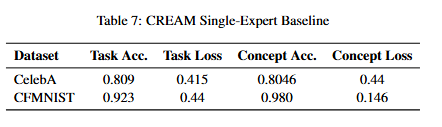

## 3. Summary Table: Task & Concept Accuracy (Mean ± Std across seeds)

In [5]:
def make_summary_table(df, metric_cols, group_cols=["dataset", "method", "M", "disagreement_level"]):
    """Aggregate metrics across seeds: mean ± std."""
    available_cols = [c for c in metric_cols if c in df.columns]
    if not available_cols:
        print("No metric columns found!")
        return pd.DataFrame()
    
    grouped = df.groupby(group_cols)[available_cols]
    means = grouped.mean()
    stds = grouped.std()
    counts = grouped.count().iloc[:, 0].rename("n_seeds")
    
    # Format as mean ± std
    summary = pd.DataFrame(index=means.index)
    summary["n_seeds"] = counts
    for col in available_cols:
        summary[col] = means[col].map(lambda x: f"{x:.4f}") + " ± " + stds[col].map(lambda x: f"{x:.4f}")
    
    return summary

if len(results_df) > 0:
    # Core metrics
    core_metrics = ["test_task_accuracy", "test_concept_accuracy", 
                    "CCI", "PFI_concept_importance", "PFI_side_importance",
                    "concept_leakage", "c2y_baseline_accuracy"]
    
    summary = make_summary_table(results_df, core_metrics)
    print("=" * 80)
    print("CORE METRICS SUMMARY (mean ± std across seeds)")
    print("=" * 80)
    display(summary)

CORE METRICS SUMMARY (mean ± std across seeds)


n_seeds  \
dataset                 method    M  disagreement_level            
CelebA                  edge      5  high                      5   
                                     low                       5   
                                     medium                    5   
                                     structured_bias           5   
                                  10 high                     10   
                                     low                      10   
                                     medium                   10   
                                     structured_bias          10   
                        graph     5  high                      5   
                                     low                       5   
                                     medium                    5   
                                     structured_bias           5   
                                  10 high                     10   
                                     low                      10   
                                     medium                   10   
                                     structured_bias          10   
                        graph_mlp 10 high                      1   
Complete_Concept_FMNIST edge      5  high                      5   
                                     low                       5   
                                     medium                    5   
                                     structured_bias           5   
                                  10 high                     10   
                                     medium                   10   
                                     structured_bias          10   
                        graph     5  high                      5   
                                     low                       5   
                                     medium                    5   
                                     structured_bias           5   
                                  10 high                     10   
                                     medium                   10   
                                     structured_bias          10   
                        graph_mlp 5  low                       5   
                                  10 high                      5   
                                     low                       5   
                                     medium                    5   

                                                        test_task_accuracy  \
dataset                 method    M  disagreement_level                      
CelebA                  edge      5  high                  0.7800 ± 0.0153   
                                     low                   0.7894 ± 0.0180   
                                     medium                0.7866 ± 0.0199   
                                     structured_bias       0.7914 ± 0.0218   
                                  10 high                  0.7831 ± 0.0150   
                                     low                   0.7928 ± 0.0195   
                                     medium                0.7927 ± 0.0205   
                                     structured_bias       0.7942 ± 0.0204   
                        graph     5  high                  0.7834 ± 0.0124   
                                     low                   0.7927 ± 0.0168   
                                     medium                0.7946 ± 0.0104   
                                     structured_bias       0.7890 ± 0.0121   
                                  10 high                  0.7803 ± 0.0087   
                                     low                   0.7880 ± 0.0160   
                                     medium                0.7893 ± 0.0195   
                                     structured_bias       0.7895 ± 0.0179   
                        graph_mlp 10 high                     0.8125 ± nan   
Complete_Concept_FMNIST edge      5  high                 

## 4. Graph Recovery Metrics

In [7]:
if len(results_df) > 0:
    graph_metrics = ["u2c_f1", "u2c_precision", "u2c_recall",
                     "c2y_f1", "c2y_precision", "c2y_recall",
                     "u2c_num_edges_learned", "u2c_num_edges_gt",
                     "c2y_num_edges_learned", "c2y_num_edges_gt",
                     "learned_u2c_corruption_pct", "learned_c2y_corruption_pct"]
    
    graph_summary = make_summary_table(results_df, graph_metrics)
    print("=" * 80)
    print("GRAPH RECOVERY METRICS")
    print("=" * 80)
    display(graph_summary)

GRAPH RECOVERY METRICS


n_seeds  \
dataset                 method    M  disagreement_level            
CelebA                  edge      5  high                      5   
                                     low                       5   
                                     medium                    5   
                                     structured_bias           5   
                                  10 high                     10   
                                     low                      10   
                                     medium                   10   
                                     structured_bias          10   
                        graph     5  high                      5   
                                     low                       5   
                                     medium                    5   
                                     structured_bias           5   
                                  10 high                     10   
                                     low                      10   
                                     medium                   10   
                                     structured_bias          10   
                        graph_mlp 10 high                      1   
Complete_Concept_FMNIST edge      5  high                      5   
                                     low                       5   
                                     medium                    5   
                                     structured_bias           5   
                                  10 high                     10   
                                     medium                   10   
                                     structured_bias          10   
                        graph     5  high                      5   
                                     low                       5   
                                     medium                    5   
                                     structured_bias           5   
                                  10 high                     10   
                                     medium                   10   
                                     structured_bias          10   
                        graph_mlp 5  low                       5   
                                  10 high                      5   
                                     low                       5   
                                     medium                    5   

                                                                  u2c_f1  \
dataset                 method    M  disagreement_level                    
CelebA                  edge      5  high                0.0000 ± 0.0000   
                                     low                 0.0364 ± 0.0813   
                                     medium              0.0000 ± 0.0000   
                                     structured_bias     0.0364 ± 0.0813   
                                  10 high                0.0000 ± 0.0000   
                                     low                 0.0364 ± 0.0767   
                                     medium              0.0000 ± 0.0000   
                                     structured_bias     0.0364 ± 0.0767   
                        graph     5  high                0.2527 ± 0.0025   
                                     low                 0.6571 ± 0.0130   
                                     medium              0.3572 ± 0.0066   
                                     structured_bias     0.5236 ± 0.0060   
                                  10 high                0.2527 ± 0.0023   
                                     low                 0.7600 ± 0.0215   
                                     medium              0.3265 ± 0.0219   
                                     structured_bias     0.5314 ± 0.0361   
                        graph_mlp 10 high                   0.3390 ± nan   
Complete_Concept_FMNIST edge      5  high                0.0000 ± 0.0000   
                    

## 5. Task Accuracy Comparison Plot

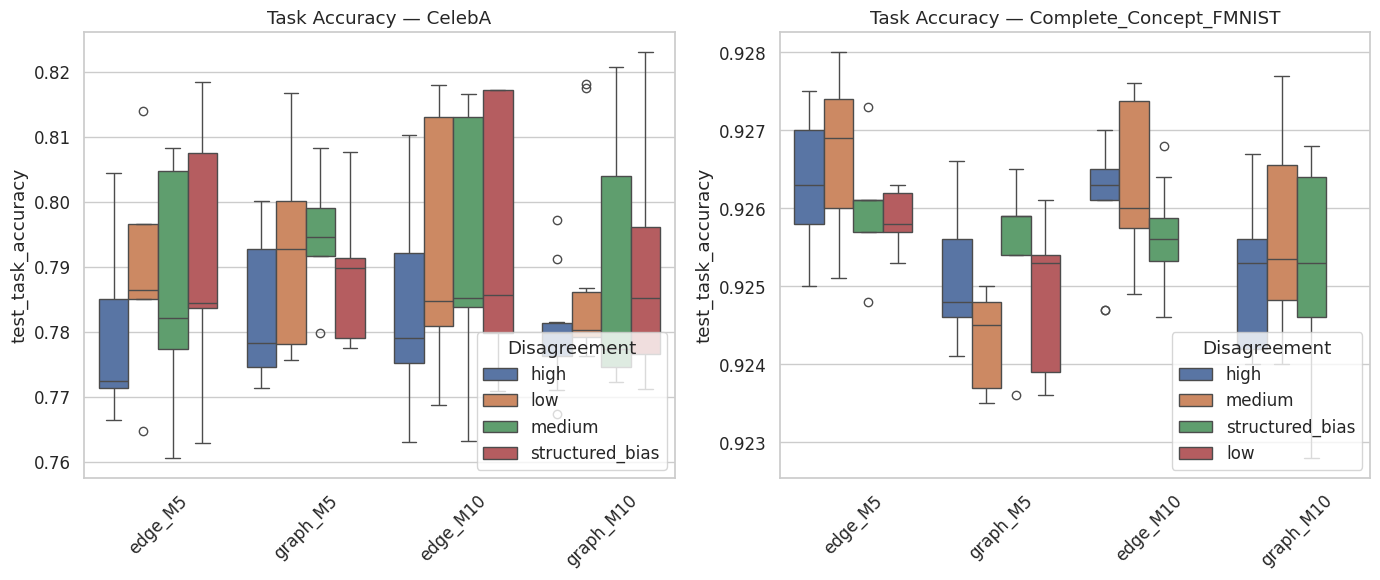

In [8]:
if len(results_df) > 0 and "test_task_accuracy" in results_df.columns:
    fig, axes = plt.subplots(1, len(DATASETS), figsize=(7*len(DATASETS), 6), squeeze=False)
    
    for idx, dataset in enumerate(DATASETS):
        ax = axes[0, idx]
        subset = results_df[results_df["dataset"] == dataset].copy()
        if subset.empty:
            continue
        
        # Create label: method_M
        subset["config"] = subset["method"] + "_M" + subset["M"].astype(str)
        
        order = ["intersection_M5", "majority_M5", "union_M5", "edge_M5", "graph_M5",
                 "intersection_M10", "majority_M10", "union_M10", "edge_M10", "graph_M10"]
        order = [o for o in order if o in subset["config"].values]
        
        sns.boxplot(data=subset, x="config", y="test_task_accuracy", 
                    hue="disagreement_level", ax=ax, order=order)
        ax.set_title(f"Task Accuracy — {dataset}")
        ax.set_xlabel("")
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title="Disagreement", loc="lower right")
    
    plt.tight_layout()
    plt.savefig("task_accuracy_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

## 6. Intervention Curves

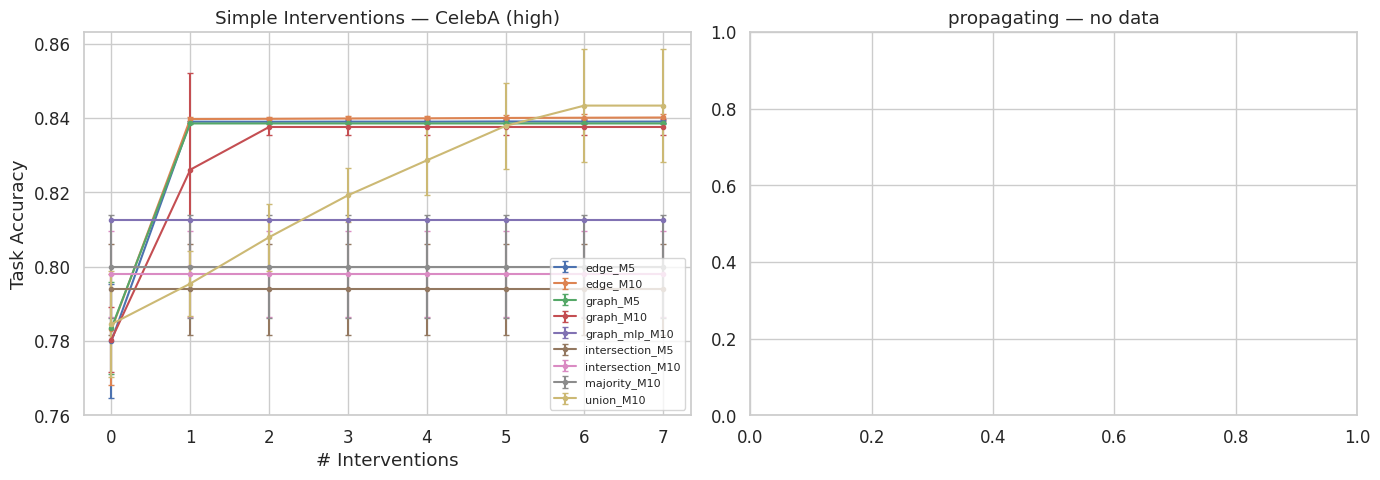

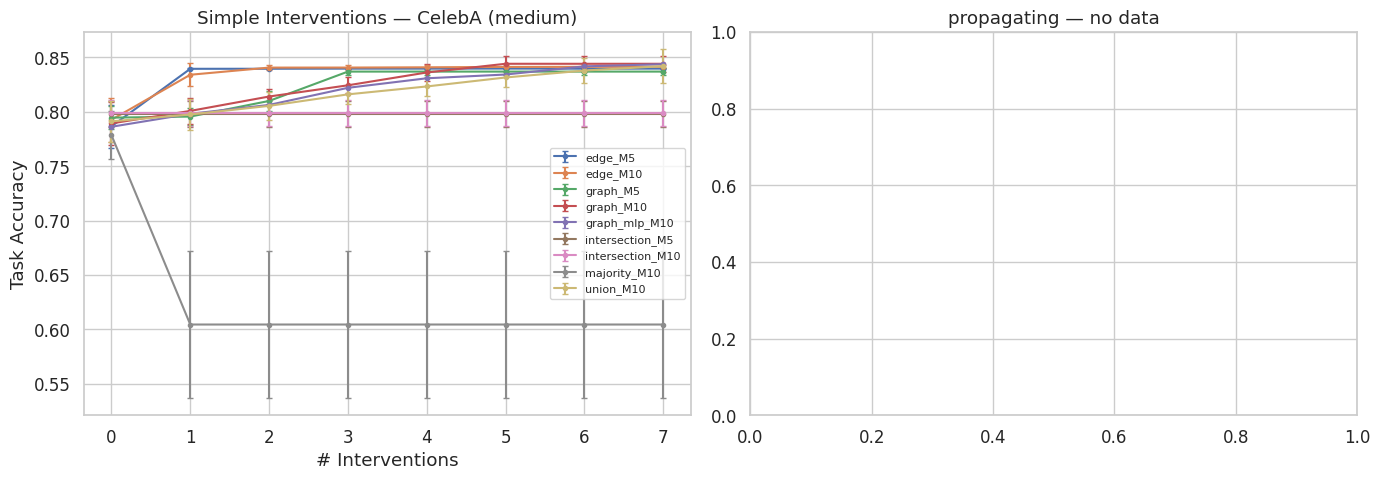

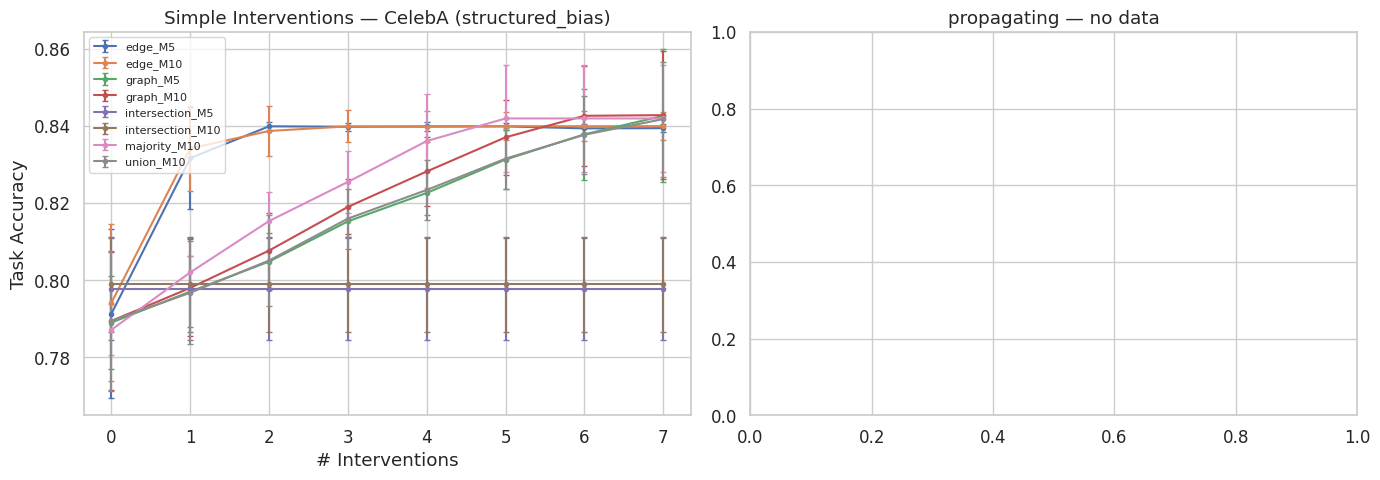

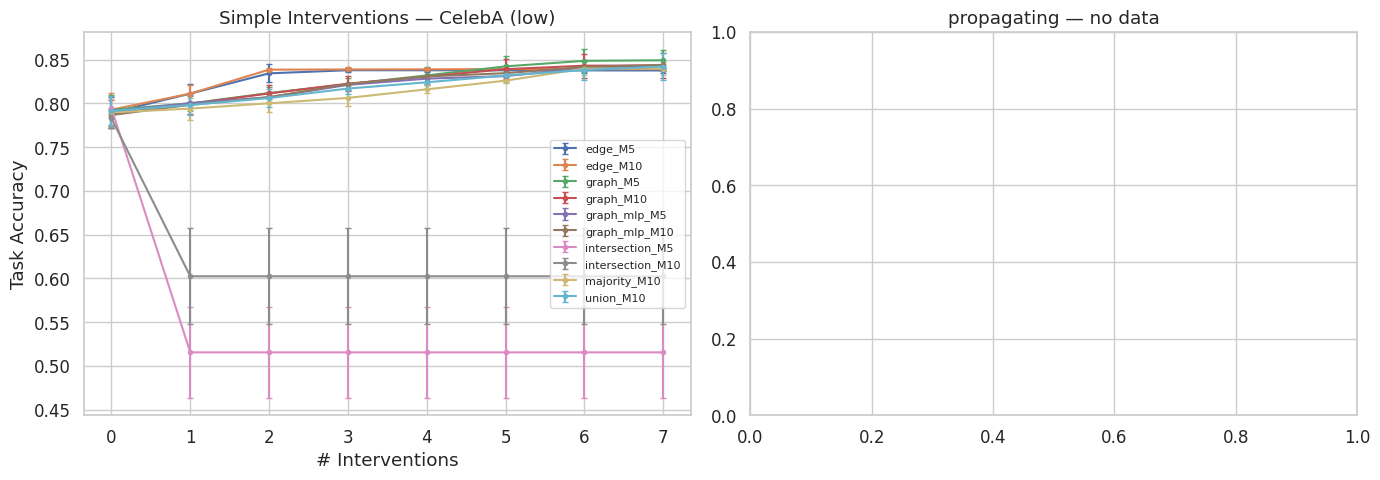

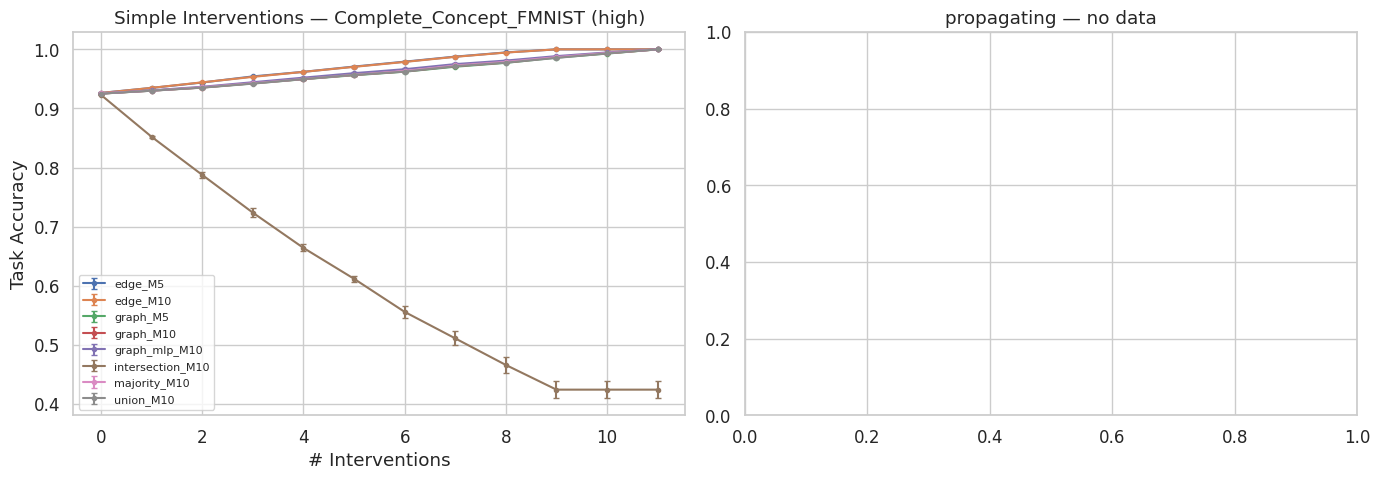

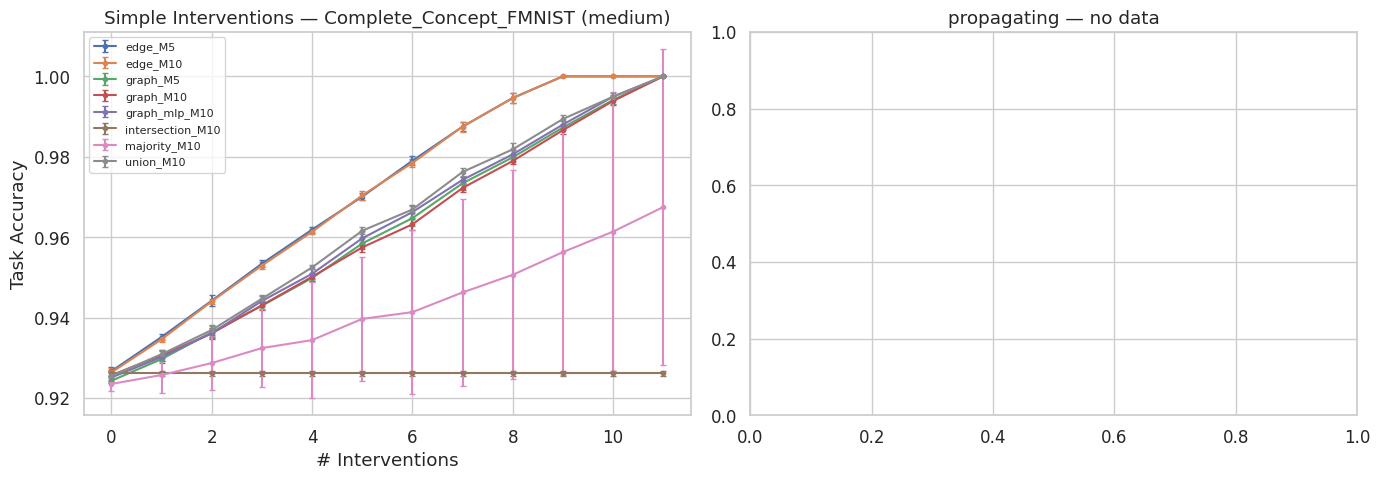

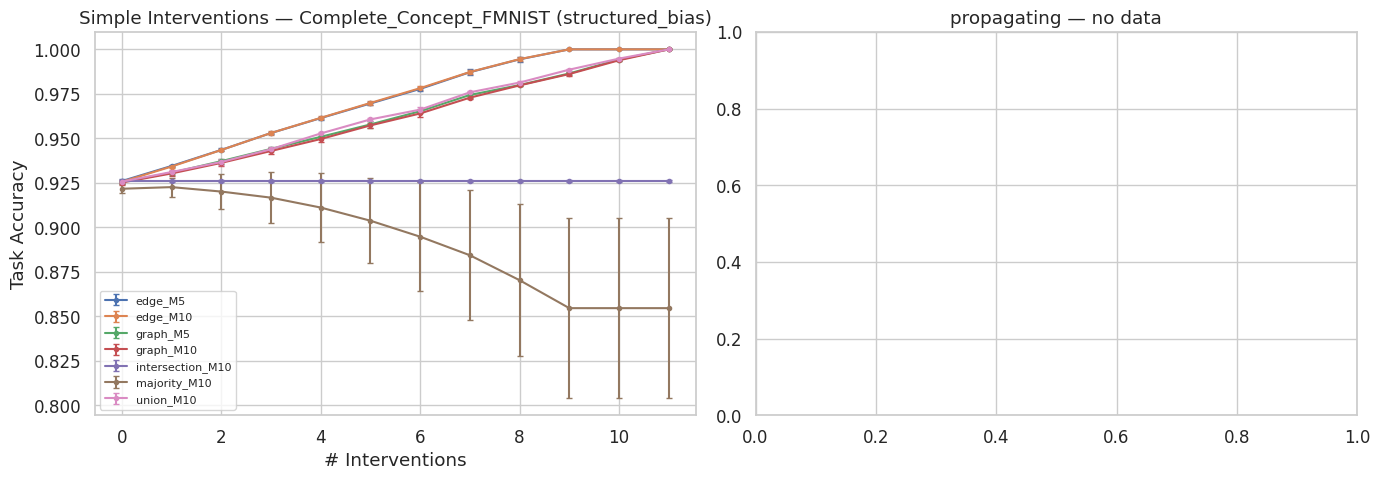

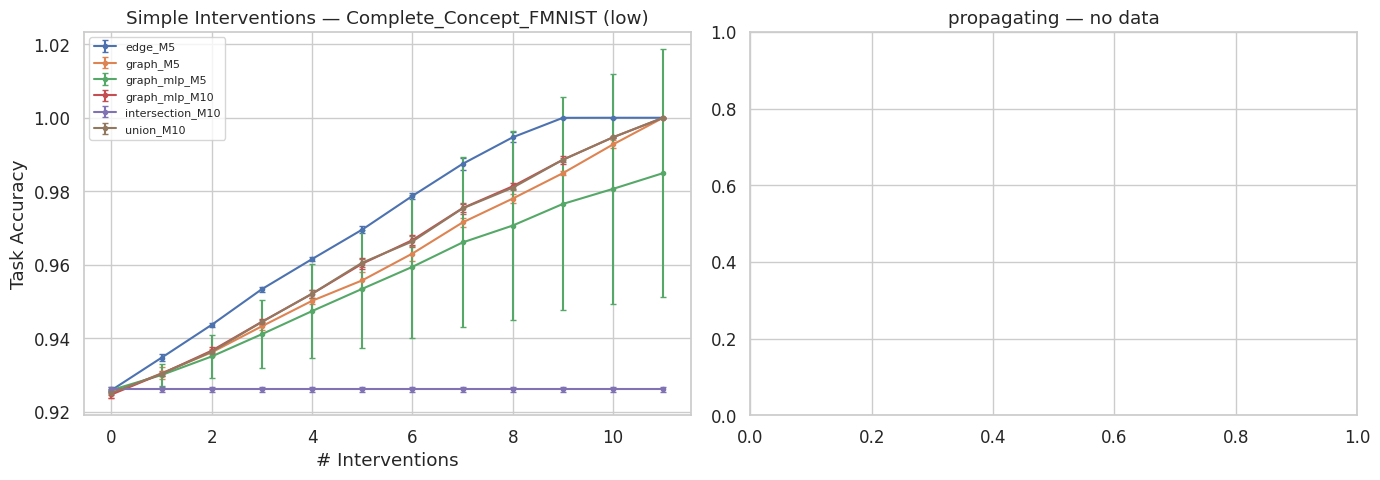

In [10]:
if len(interventions_df) > 0:
    # Plot intervention curves: accuracy vs num_interventions, grouped by method
    for dataset in DATASETS:
        for level in interventions_df["disagreement_level"].unique():
            subset = interventions_df[
                (interventions_df["dataset"] == dataset) & 
                (interventions_df["disagreement_level"] == level)
            ]
            if subset.empty:
                continue
            
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            for ax, mode in zip(axes, ["simple", "propagating"]):
                mode_data = subset[subset["mode"] == mode]
                if mode_data.empty:
                    ax.set_title(f"{mode} — no data")
                    continue
                
                # Mean across seeds per method+M+num_interventions
                agg = mode_data.groupby(["method", "M", "num_interventions"])["test_task_accuracy"].agg(["mean", "std"]).reset_index()
                
                for (method, m_val), grp in agg.groupby(["method", "M"]):
                    label = f"{method}_M{m_val}"
                    ax.errorbar(grp["num_interventions"], grp["mean"], 
                               yerr=grp["std"], label=label, marker='o', markersize=3, capsize=2)
                
                ax.set_xlabel("# Interventions")
                ax.set_ylabel("Task Accuracy")
                ax.set_title(f"{mode.capitalize()} Interventions — {dataset} ({level})")
                ax.legend(fontsize=8)
            
            plt.tight_layout()
            plt.savefig(f"interventions_{dataset}_{level}.png", dpi=150, bbox_inches="tight")
            plt.show()

## 7. Graph Recovery: F1 Scores (Edge vs Graph vs Baselines)

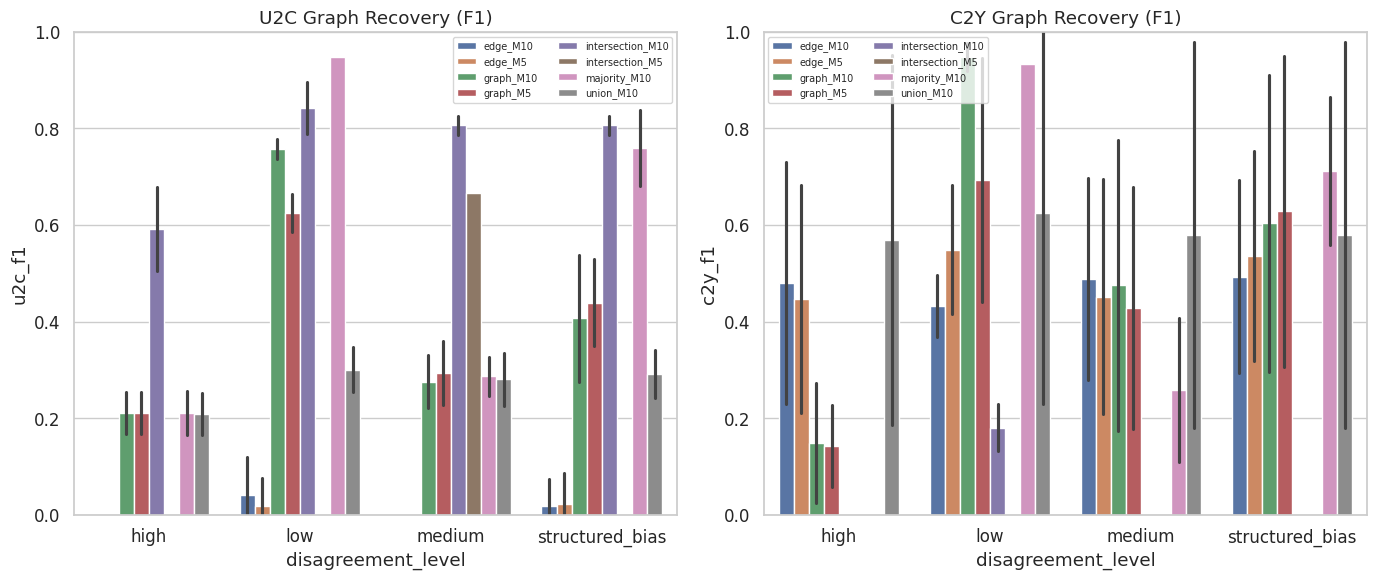

In [9]:
if len(results_df) > 0 and "u2c_f1" in results_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for ax, graph_type in zip(axes, ["u2c", "c2y"]):
        col = f"{graph_type}_f1"
        if col not in results_df.columns:
            continue
        
        subset = results_df.dropna(subset=[col]).copy()
        subset["config"] = subset["method"] + "_M" + subset["M"].astype(str)
        
        sns.barplot(data=subset, x="disagreement_level", y=col, 
                   hue="config", ax=ax, errorbar="sd")
        ax.set_title(f"{graph_type.upper()} Graph Recovery (F1)")
        ax.set_ylim(0, 1)
        ax.legend(fontsize=7, ncol=2)
    
    plt.tight_layout()
    plt.savefig("graph_recovery_f1.png", dpi=150, bbox_inches="tight")
    plt.show()

## 8. CCI and PFI: Concept Reliance

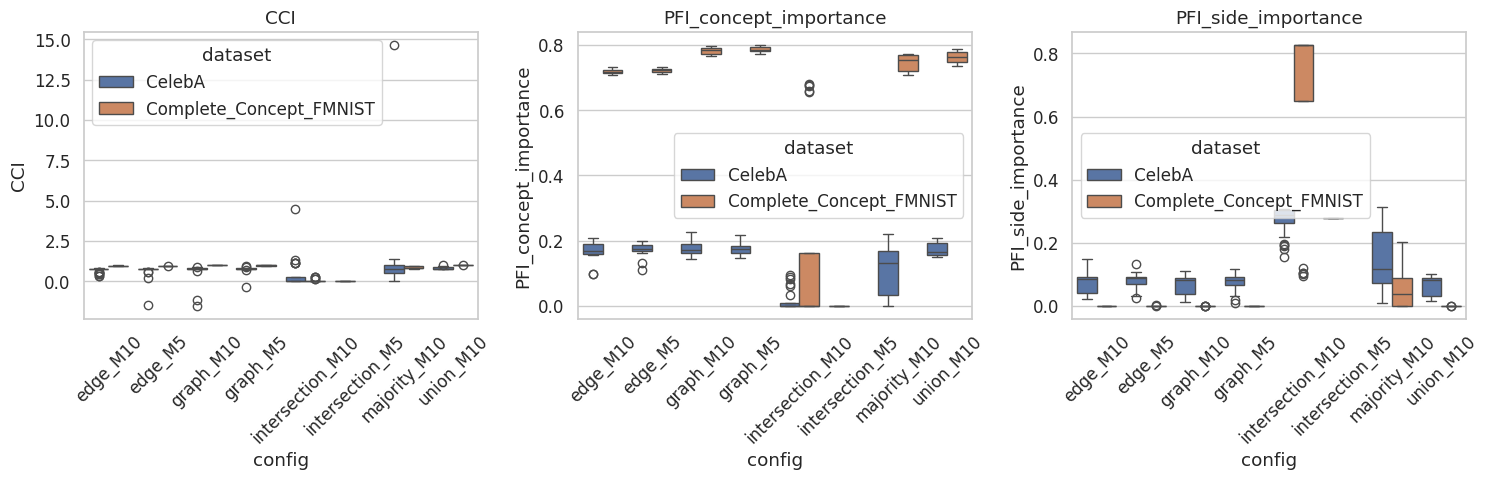

In [10]:
if len(results_df) > 0:
    cci_pfi_cols = ["CCI", "PFI_concept_importance", "PFI_side_importance"]
    available = [c for c in cci_pfi_cols if c in results_df.columns]
    
    if available:
        fig, axes = plt.subplots(1, len(available), figsize=(5*len(available), 5))
        if len(available) == 1:
            axes = [axes]
        
        for ax, col in zip(axes, available):
            subset = results_df.dropna(subset=[col]).copy()
            if subset.empty:
                continue
            subset["config"] = subset["method"] + "_M" + subset["M"].astype(str)
            
            sns.boxplot(data=subset, x="config", y=col, hue="dataset", ax=ax)
            ax.set_title(col)
            ax.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.savefig("cci_pfi_comparison.png", dpi=150, bbox_inches="tight")
        plt.show()

## 9. Concept Leakage Analysis

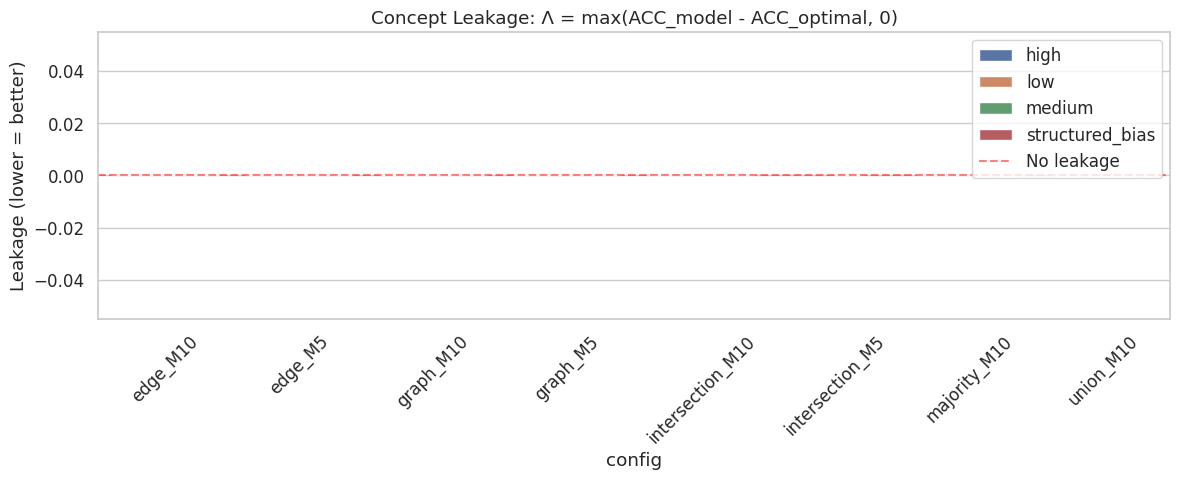

In [11]:
if len(results_df) > 0 and "concept_leakage" in results_df.columns:
    leakage_df = results_df.dropna(subset=["concept_leakage"]).copy()
    
    if not leakage_df.empty:
        leakage_df["config"] = leakage_df["method"] + "_M" + leakage_df["M"].astype(str)
        
        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(data=leakage_df, x="config", y="concept_leakage", 
                   hue="disagreement_level", ax=ax, errorbar="sd")
        ax.set_title("Concept Leakage: Λ = max(ACC_model - ACC_optimal, 0)")
        ax.set_ylabel("Leakage (lower = better)")
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label="No leakage")
        ax.tick_params(axis='x', rotation=45)
        ax.legend()
        plt.tight_layout()
        plt.savefig("concept_leakage.png", dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("No leakage data available.")

## 10. Learned Graph Visualization (Example)

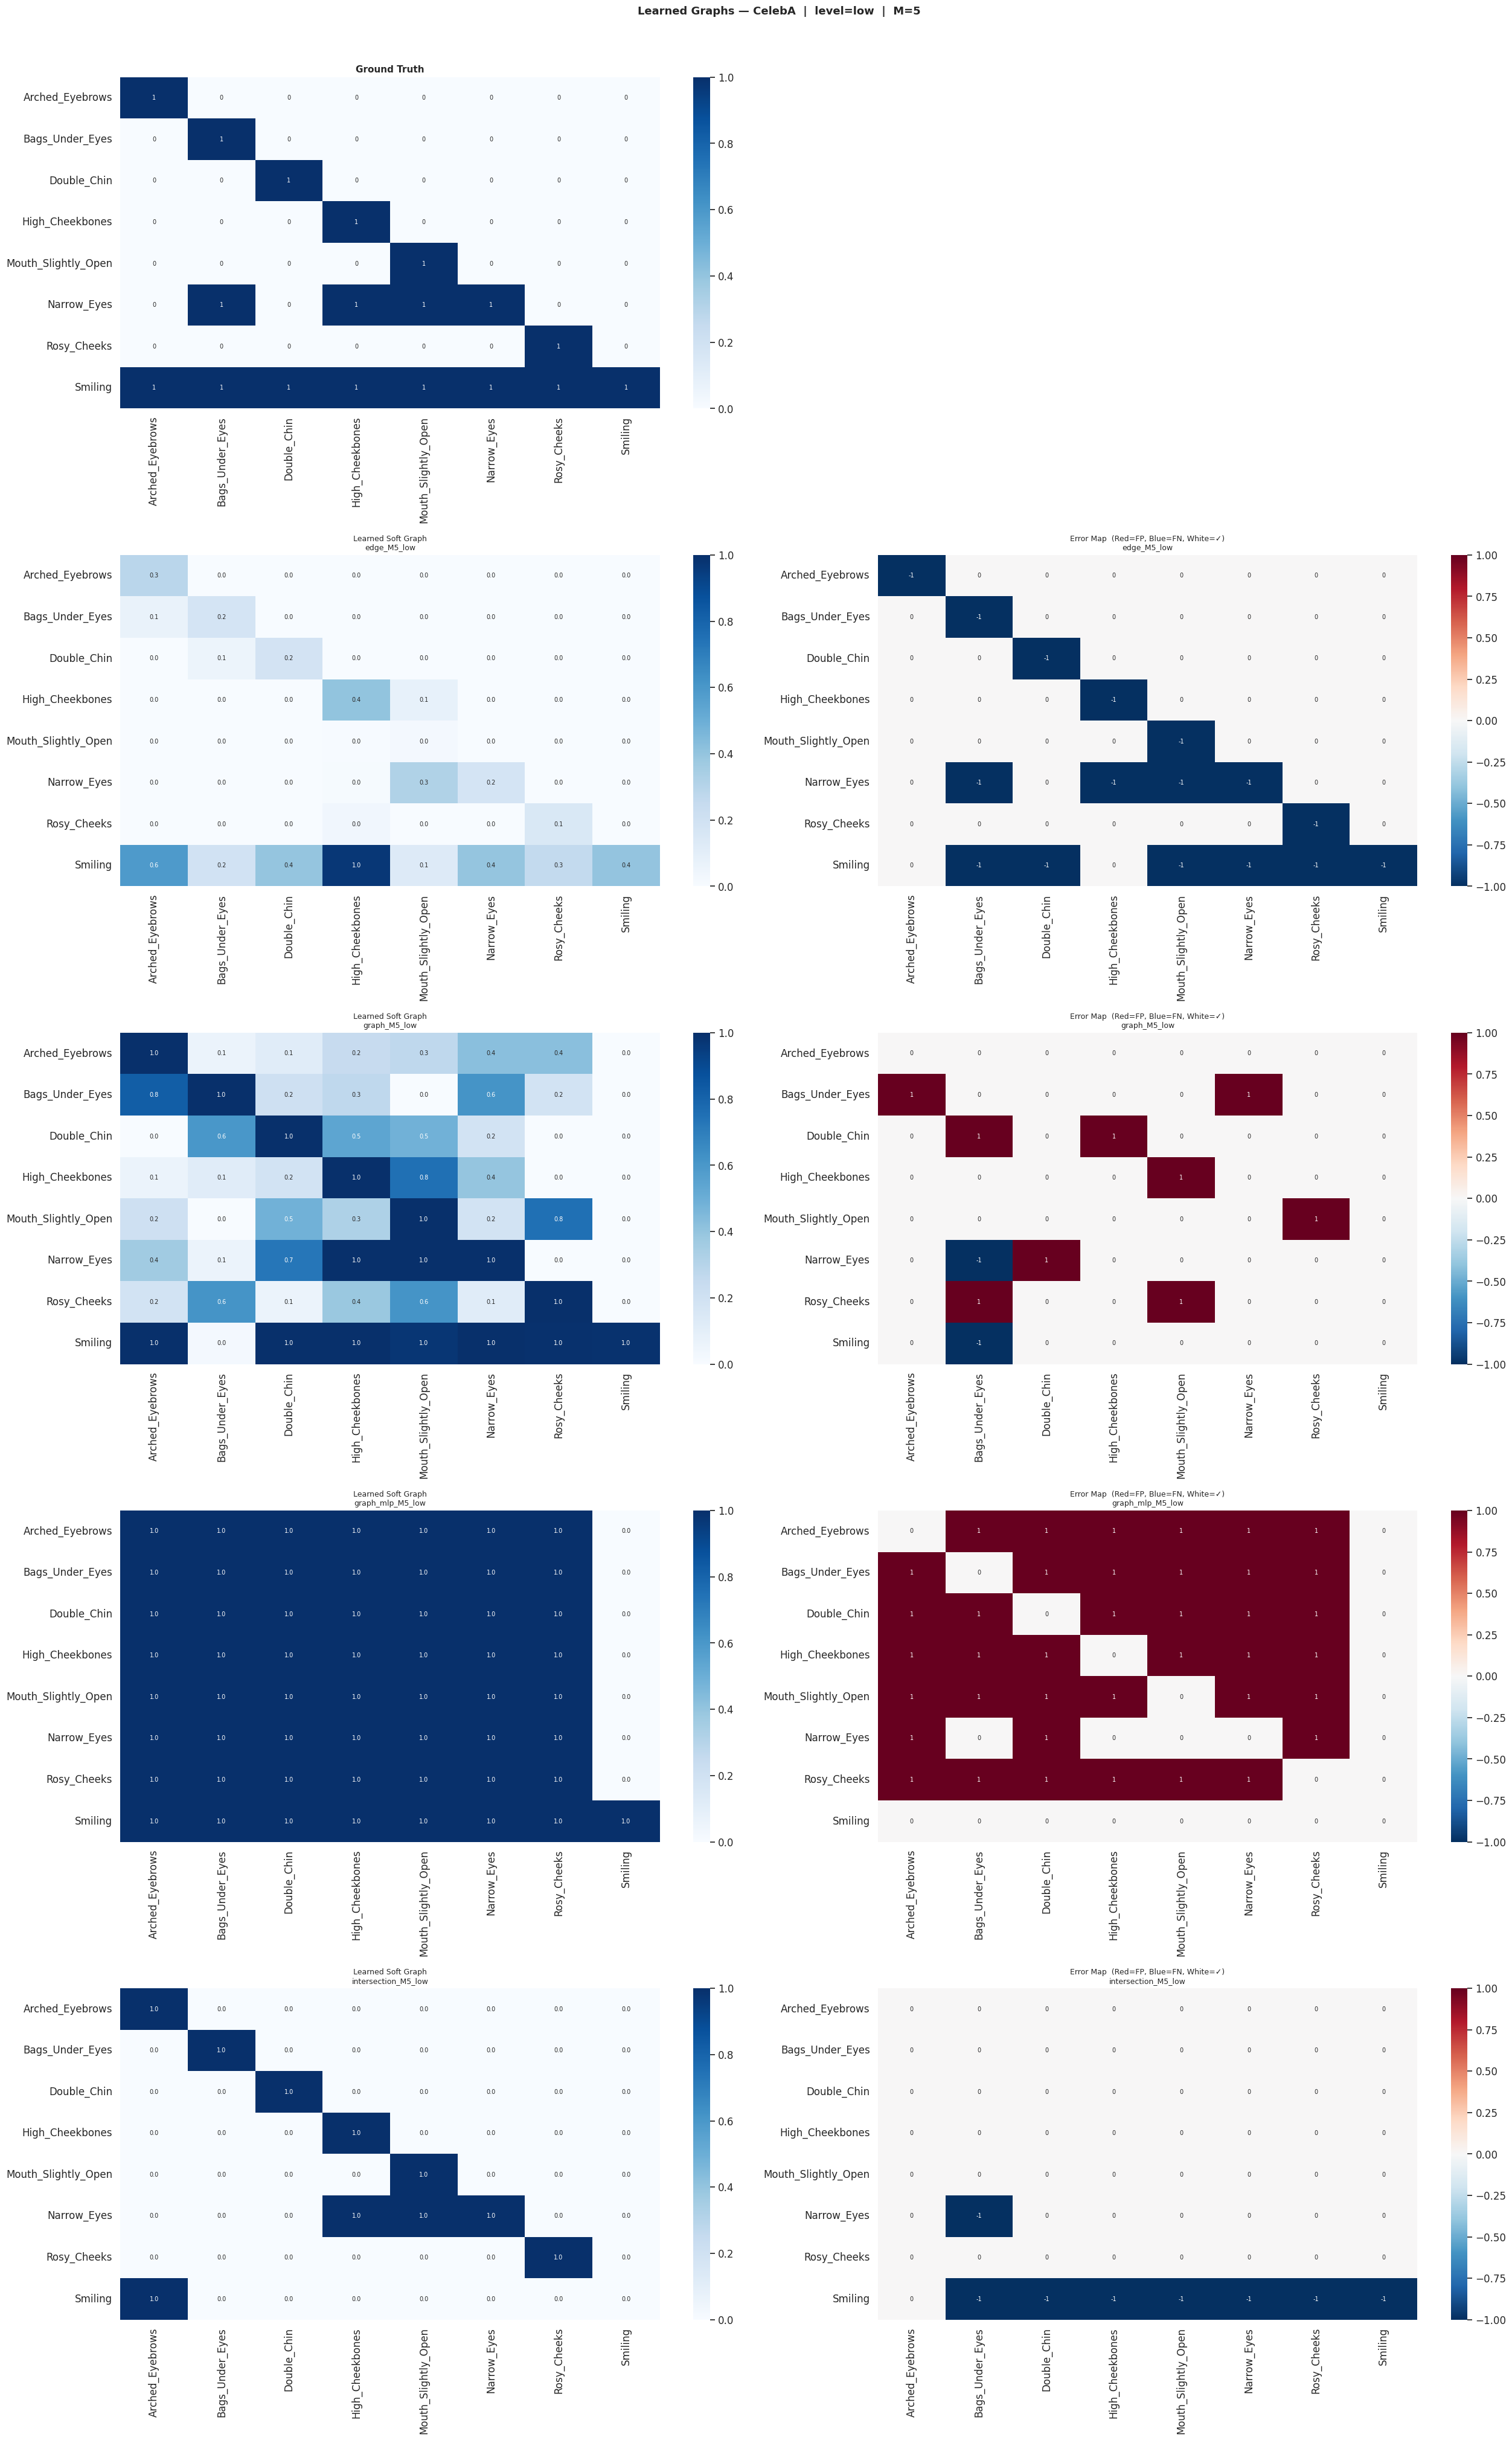

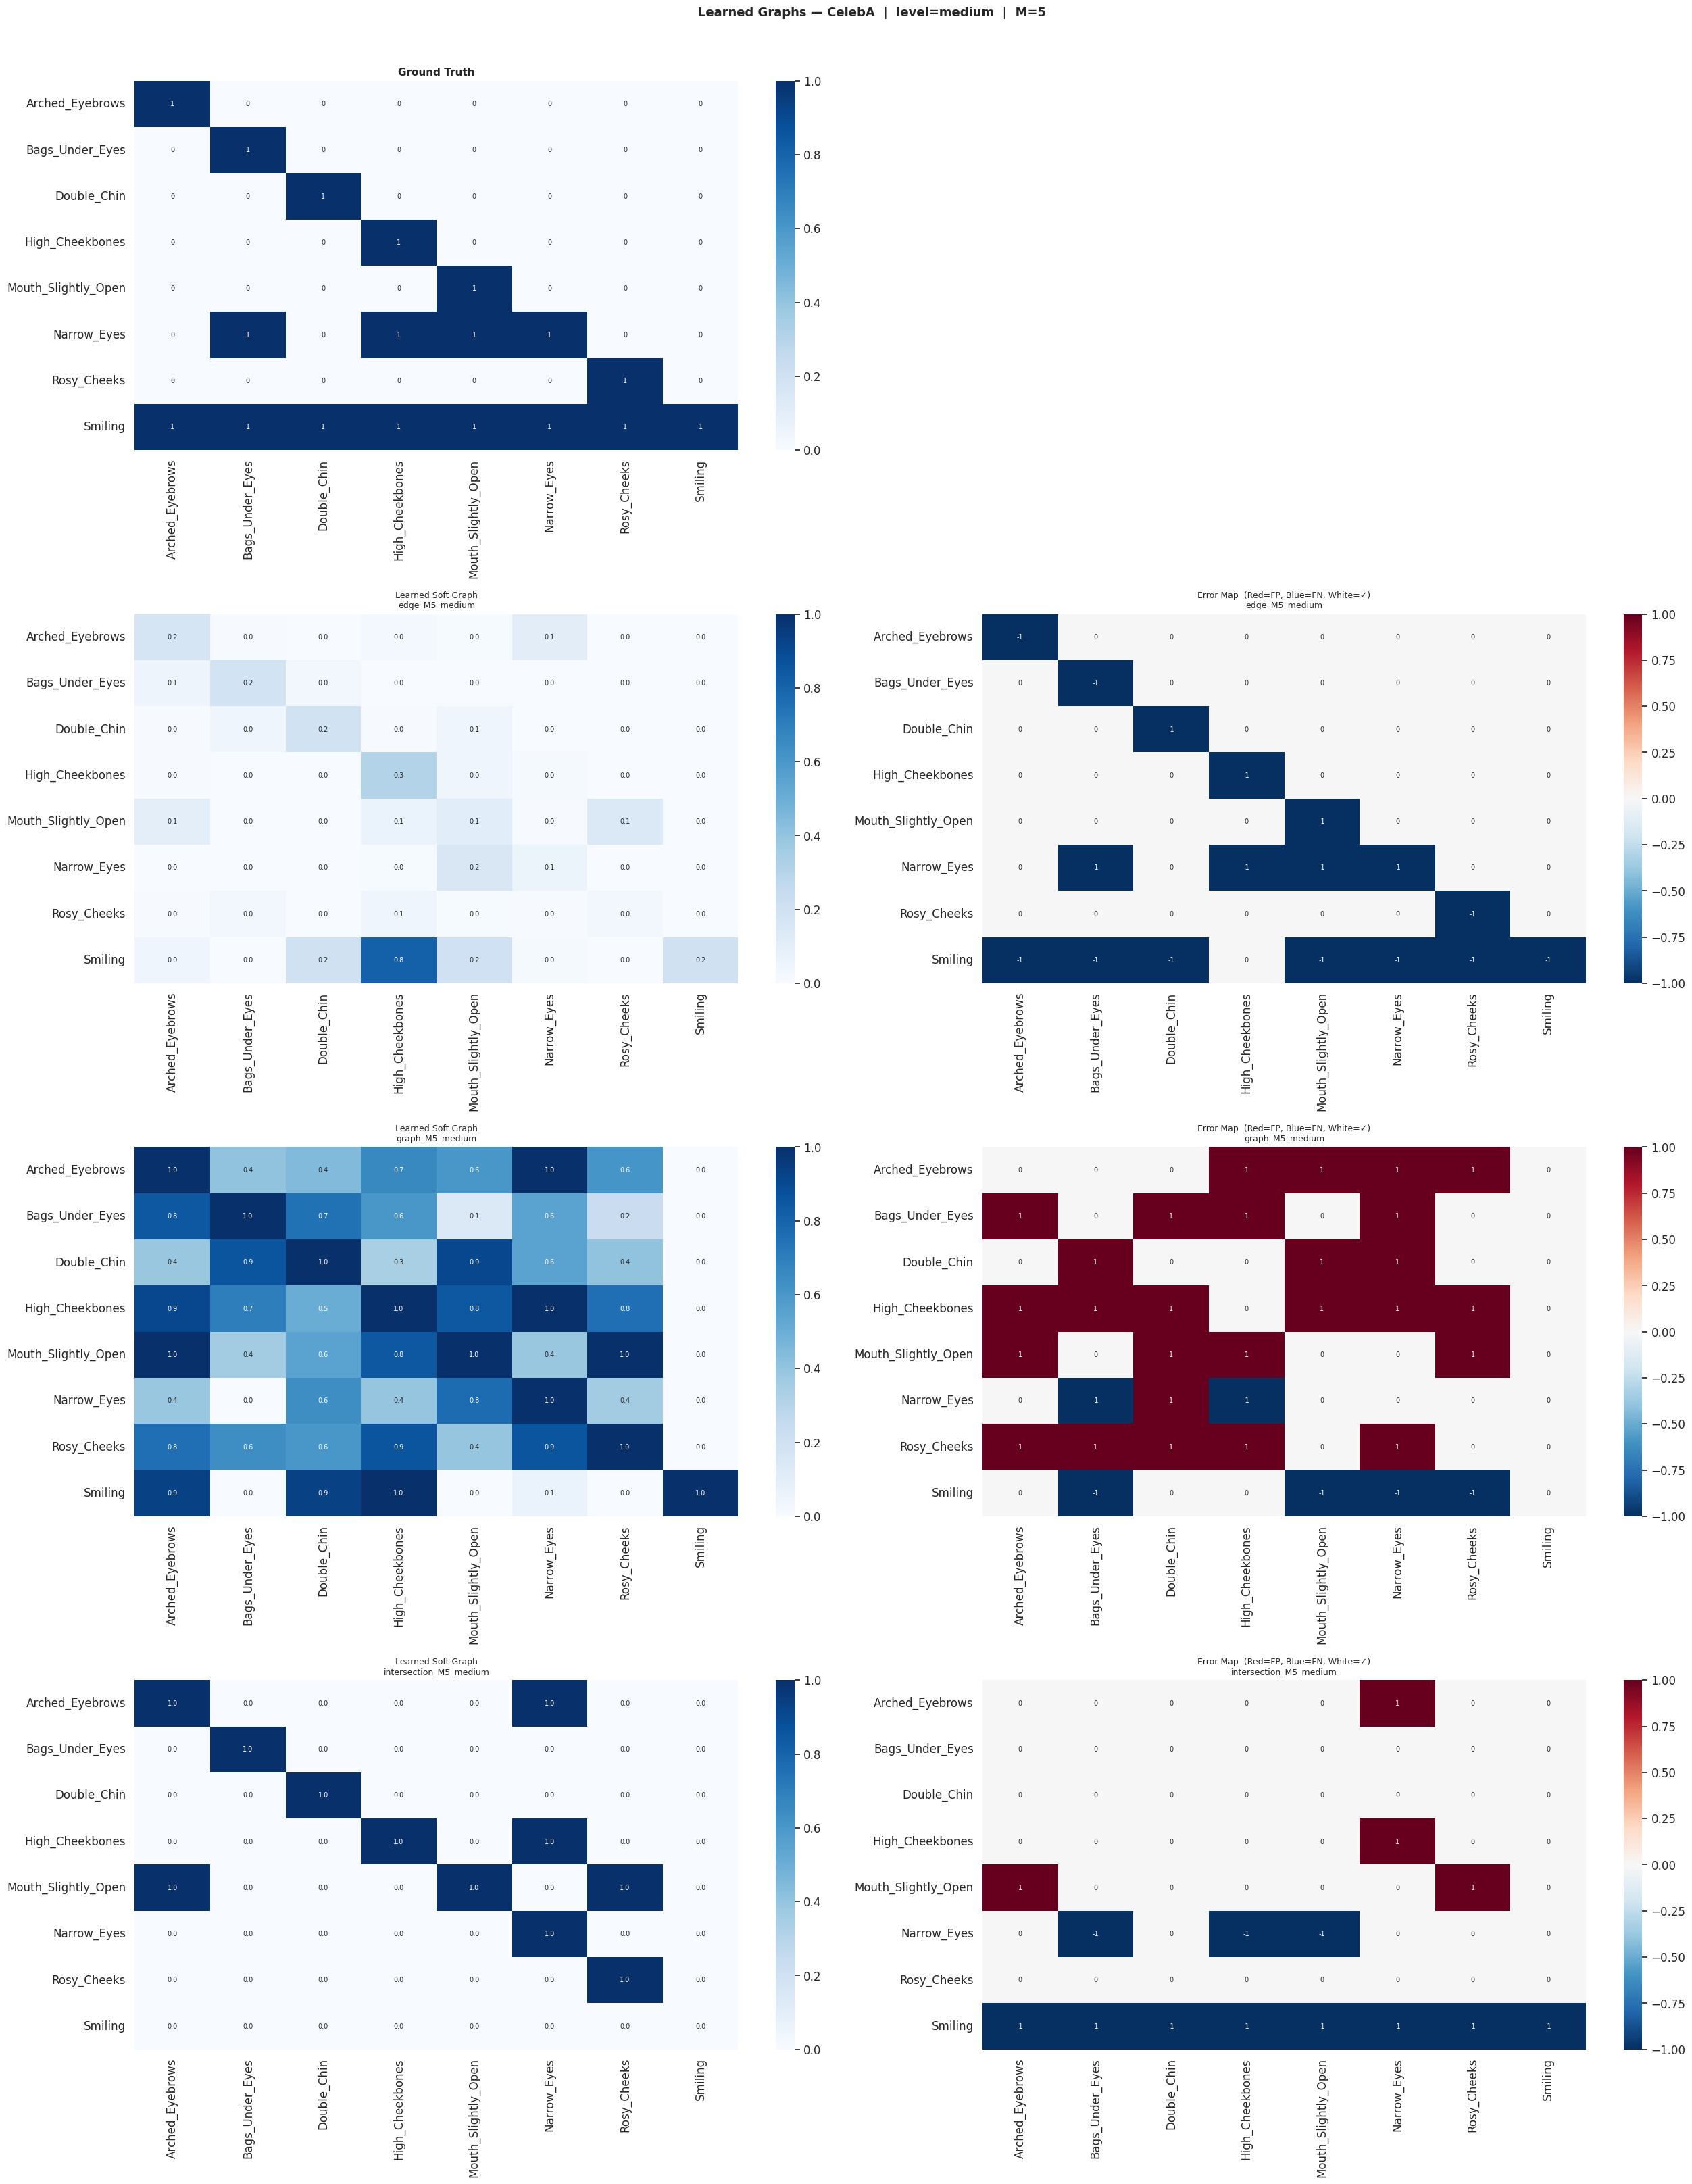

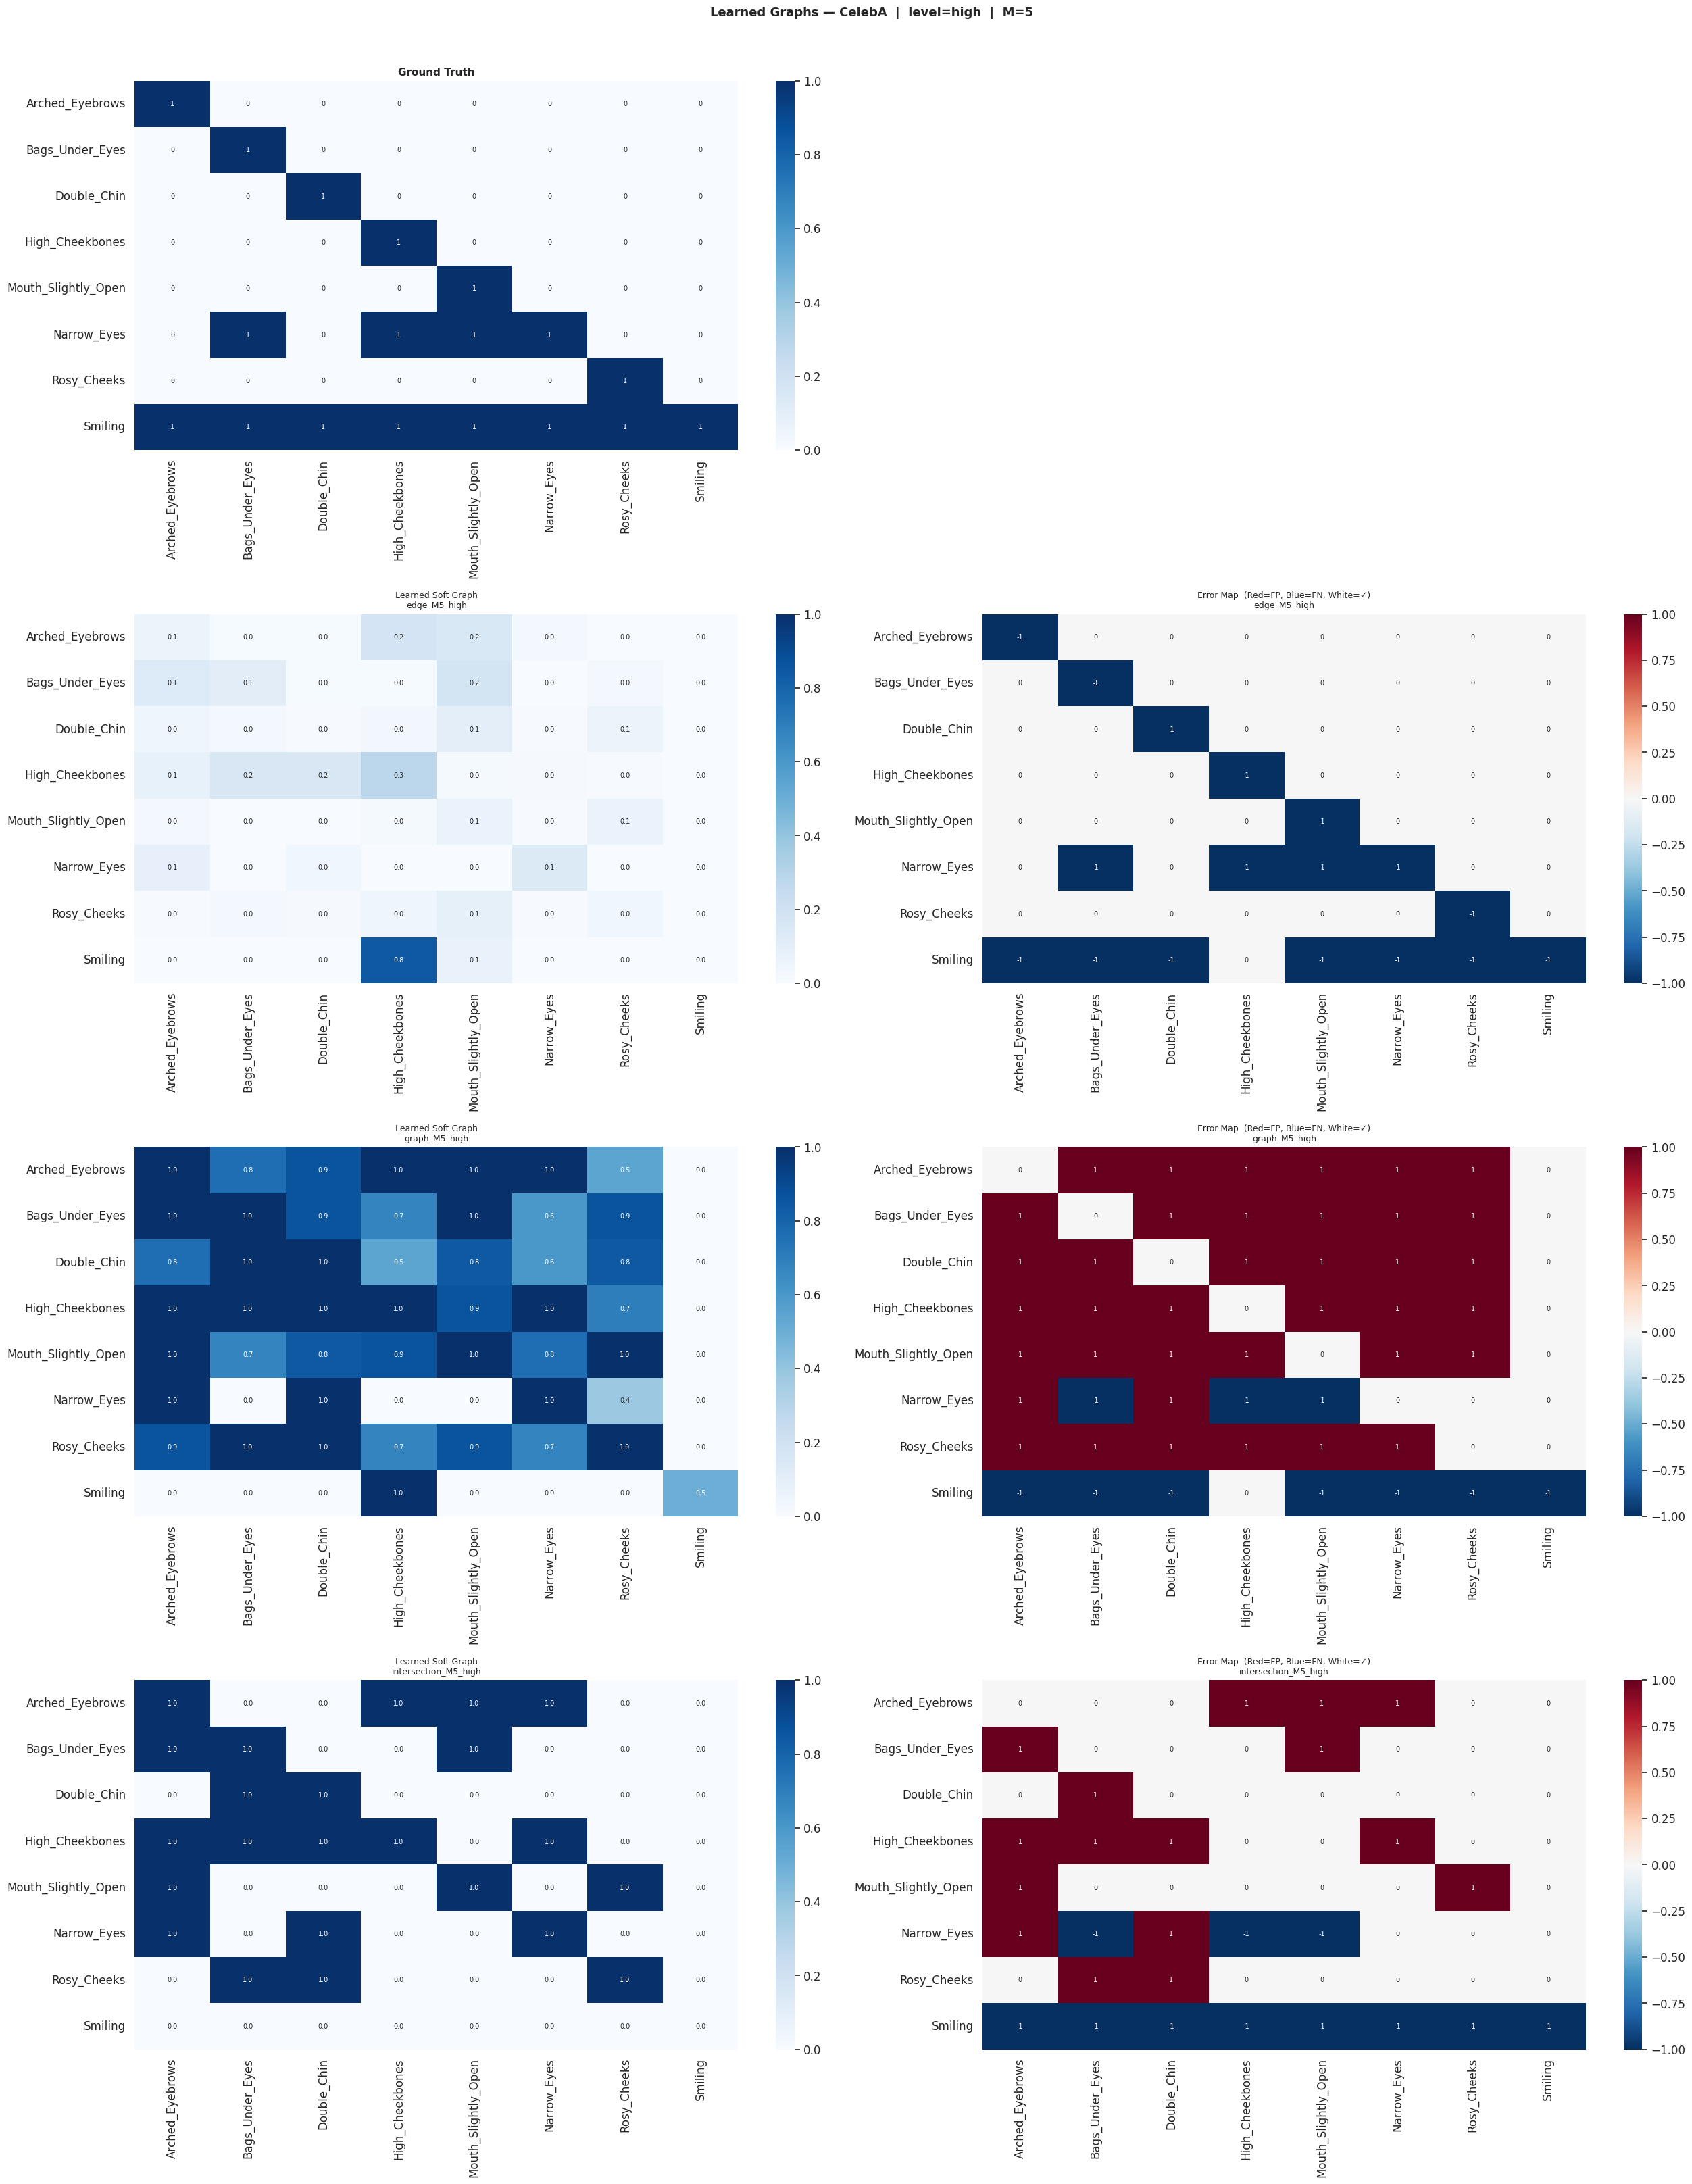

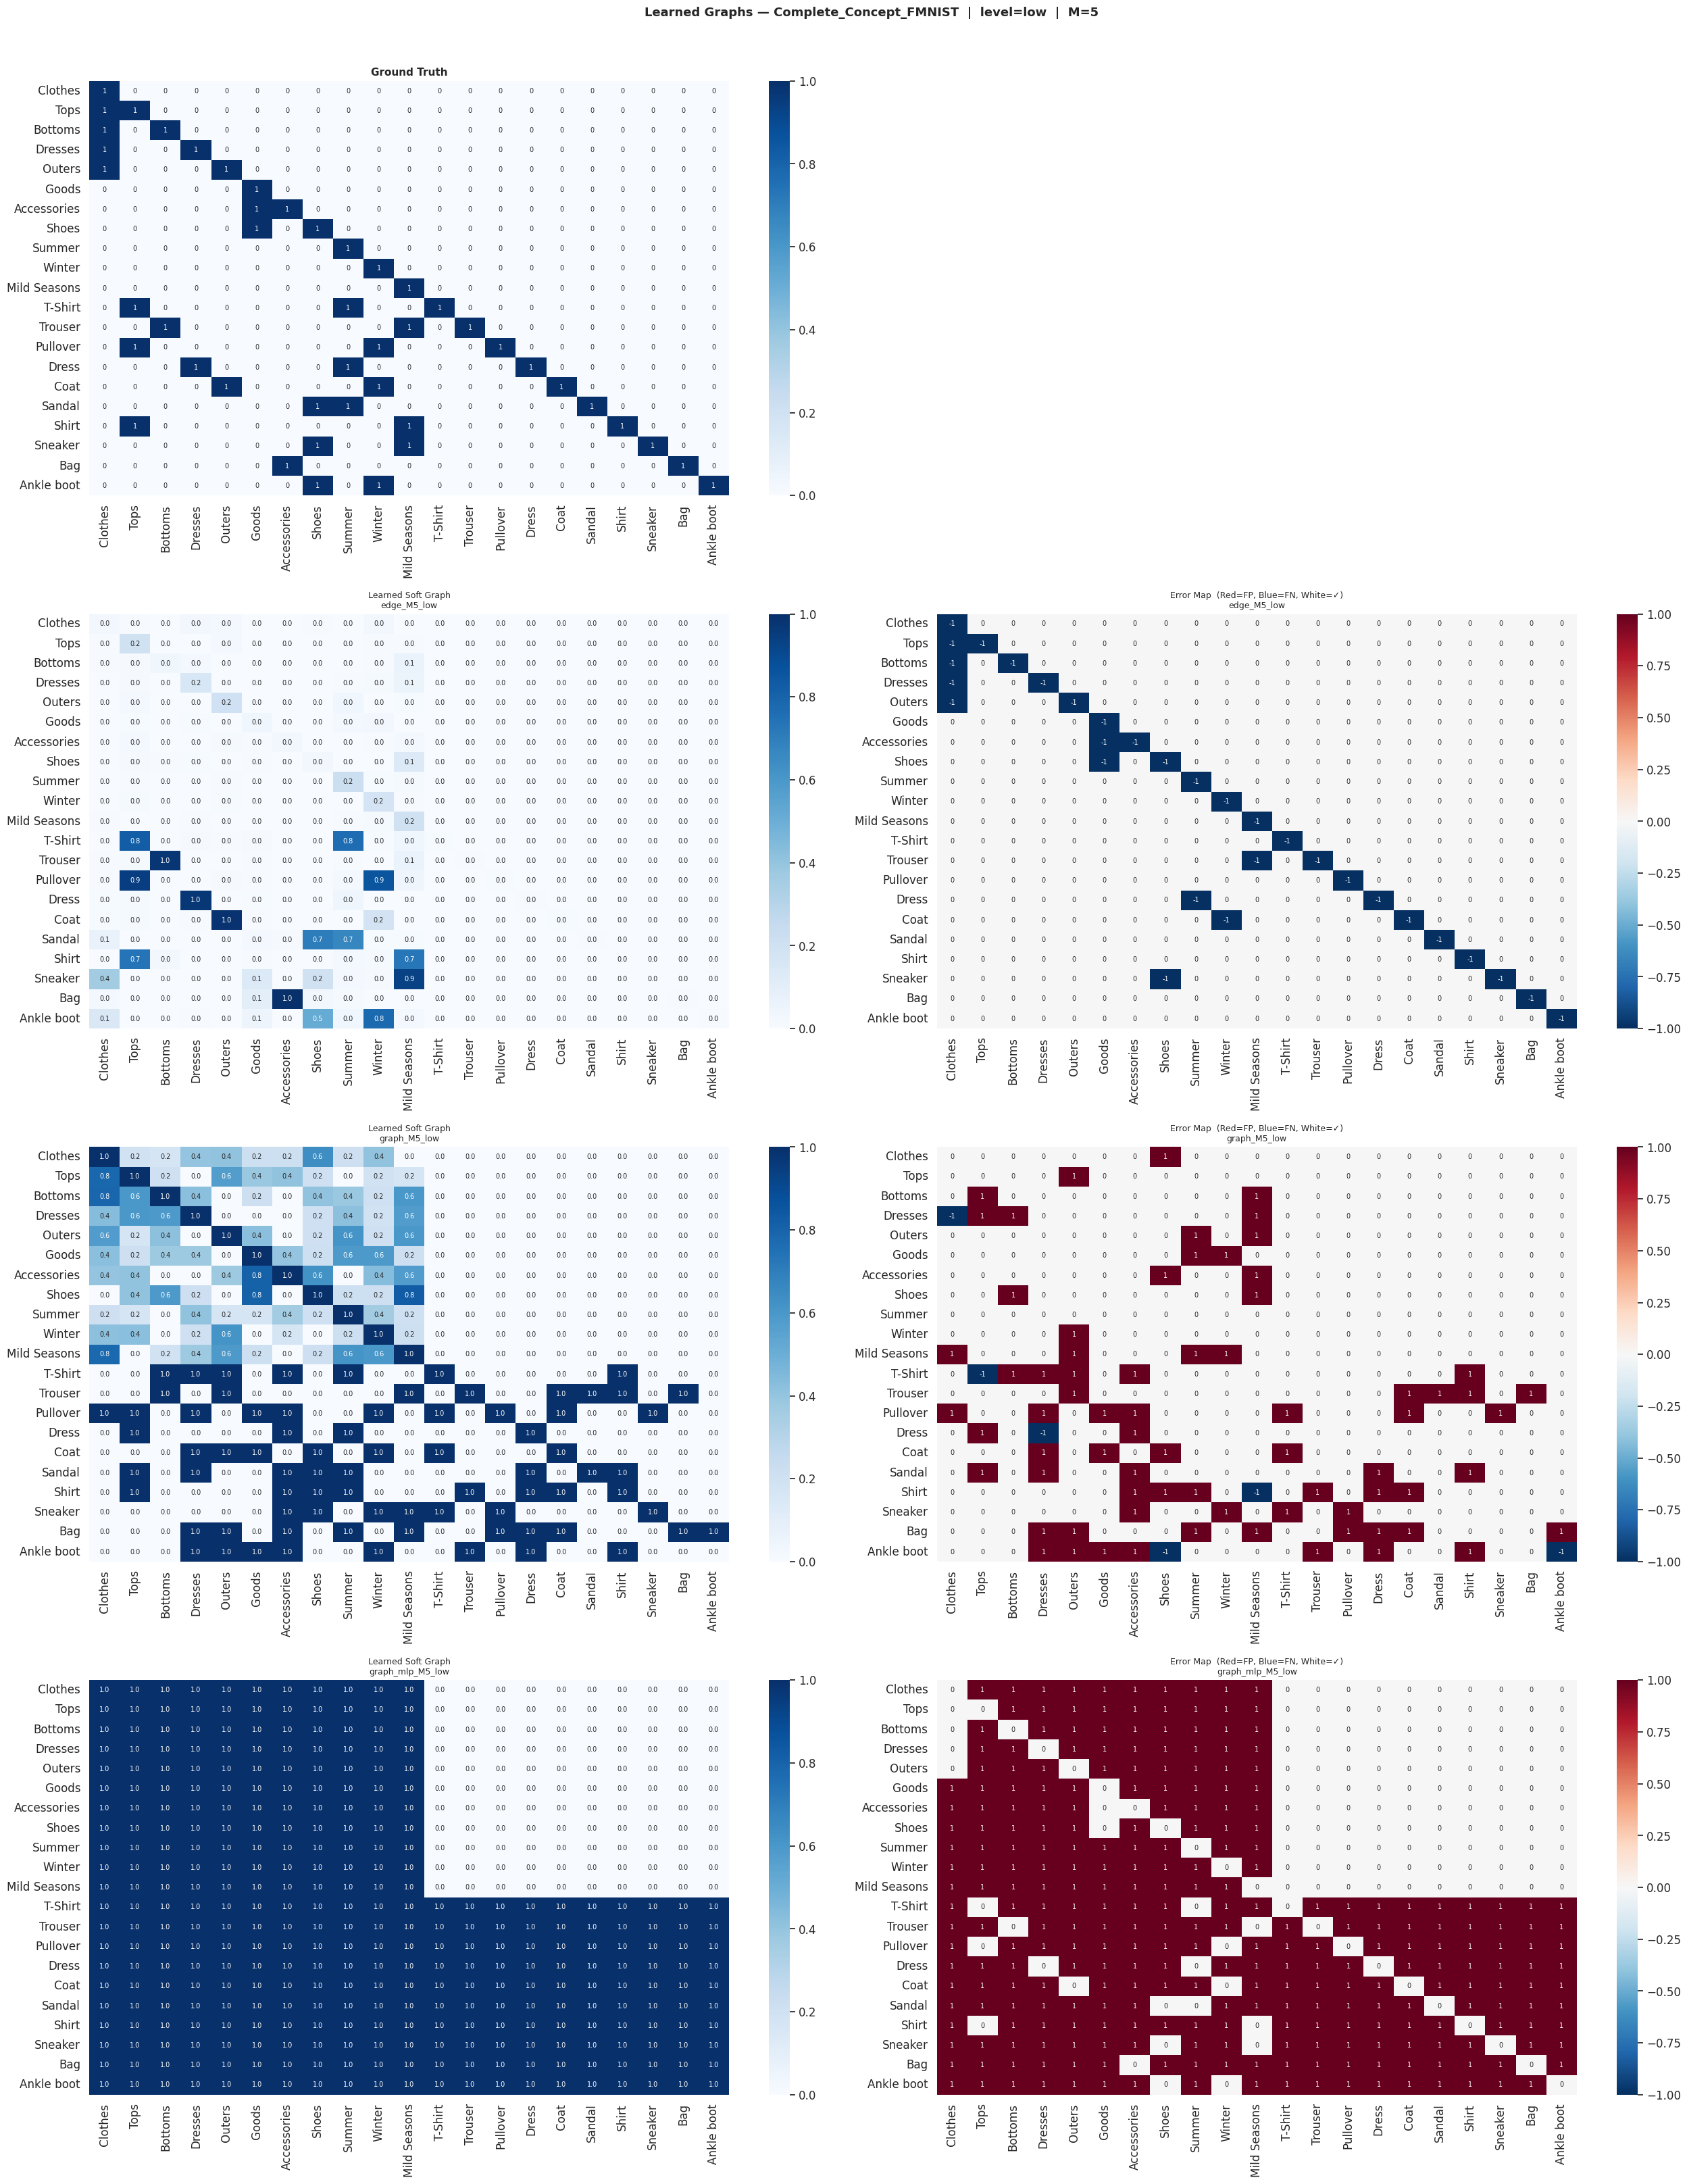

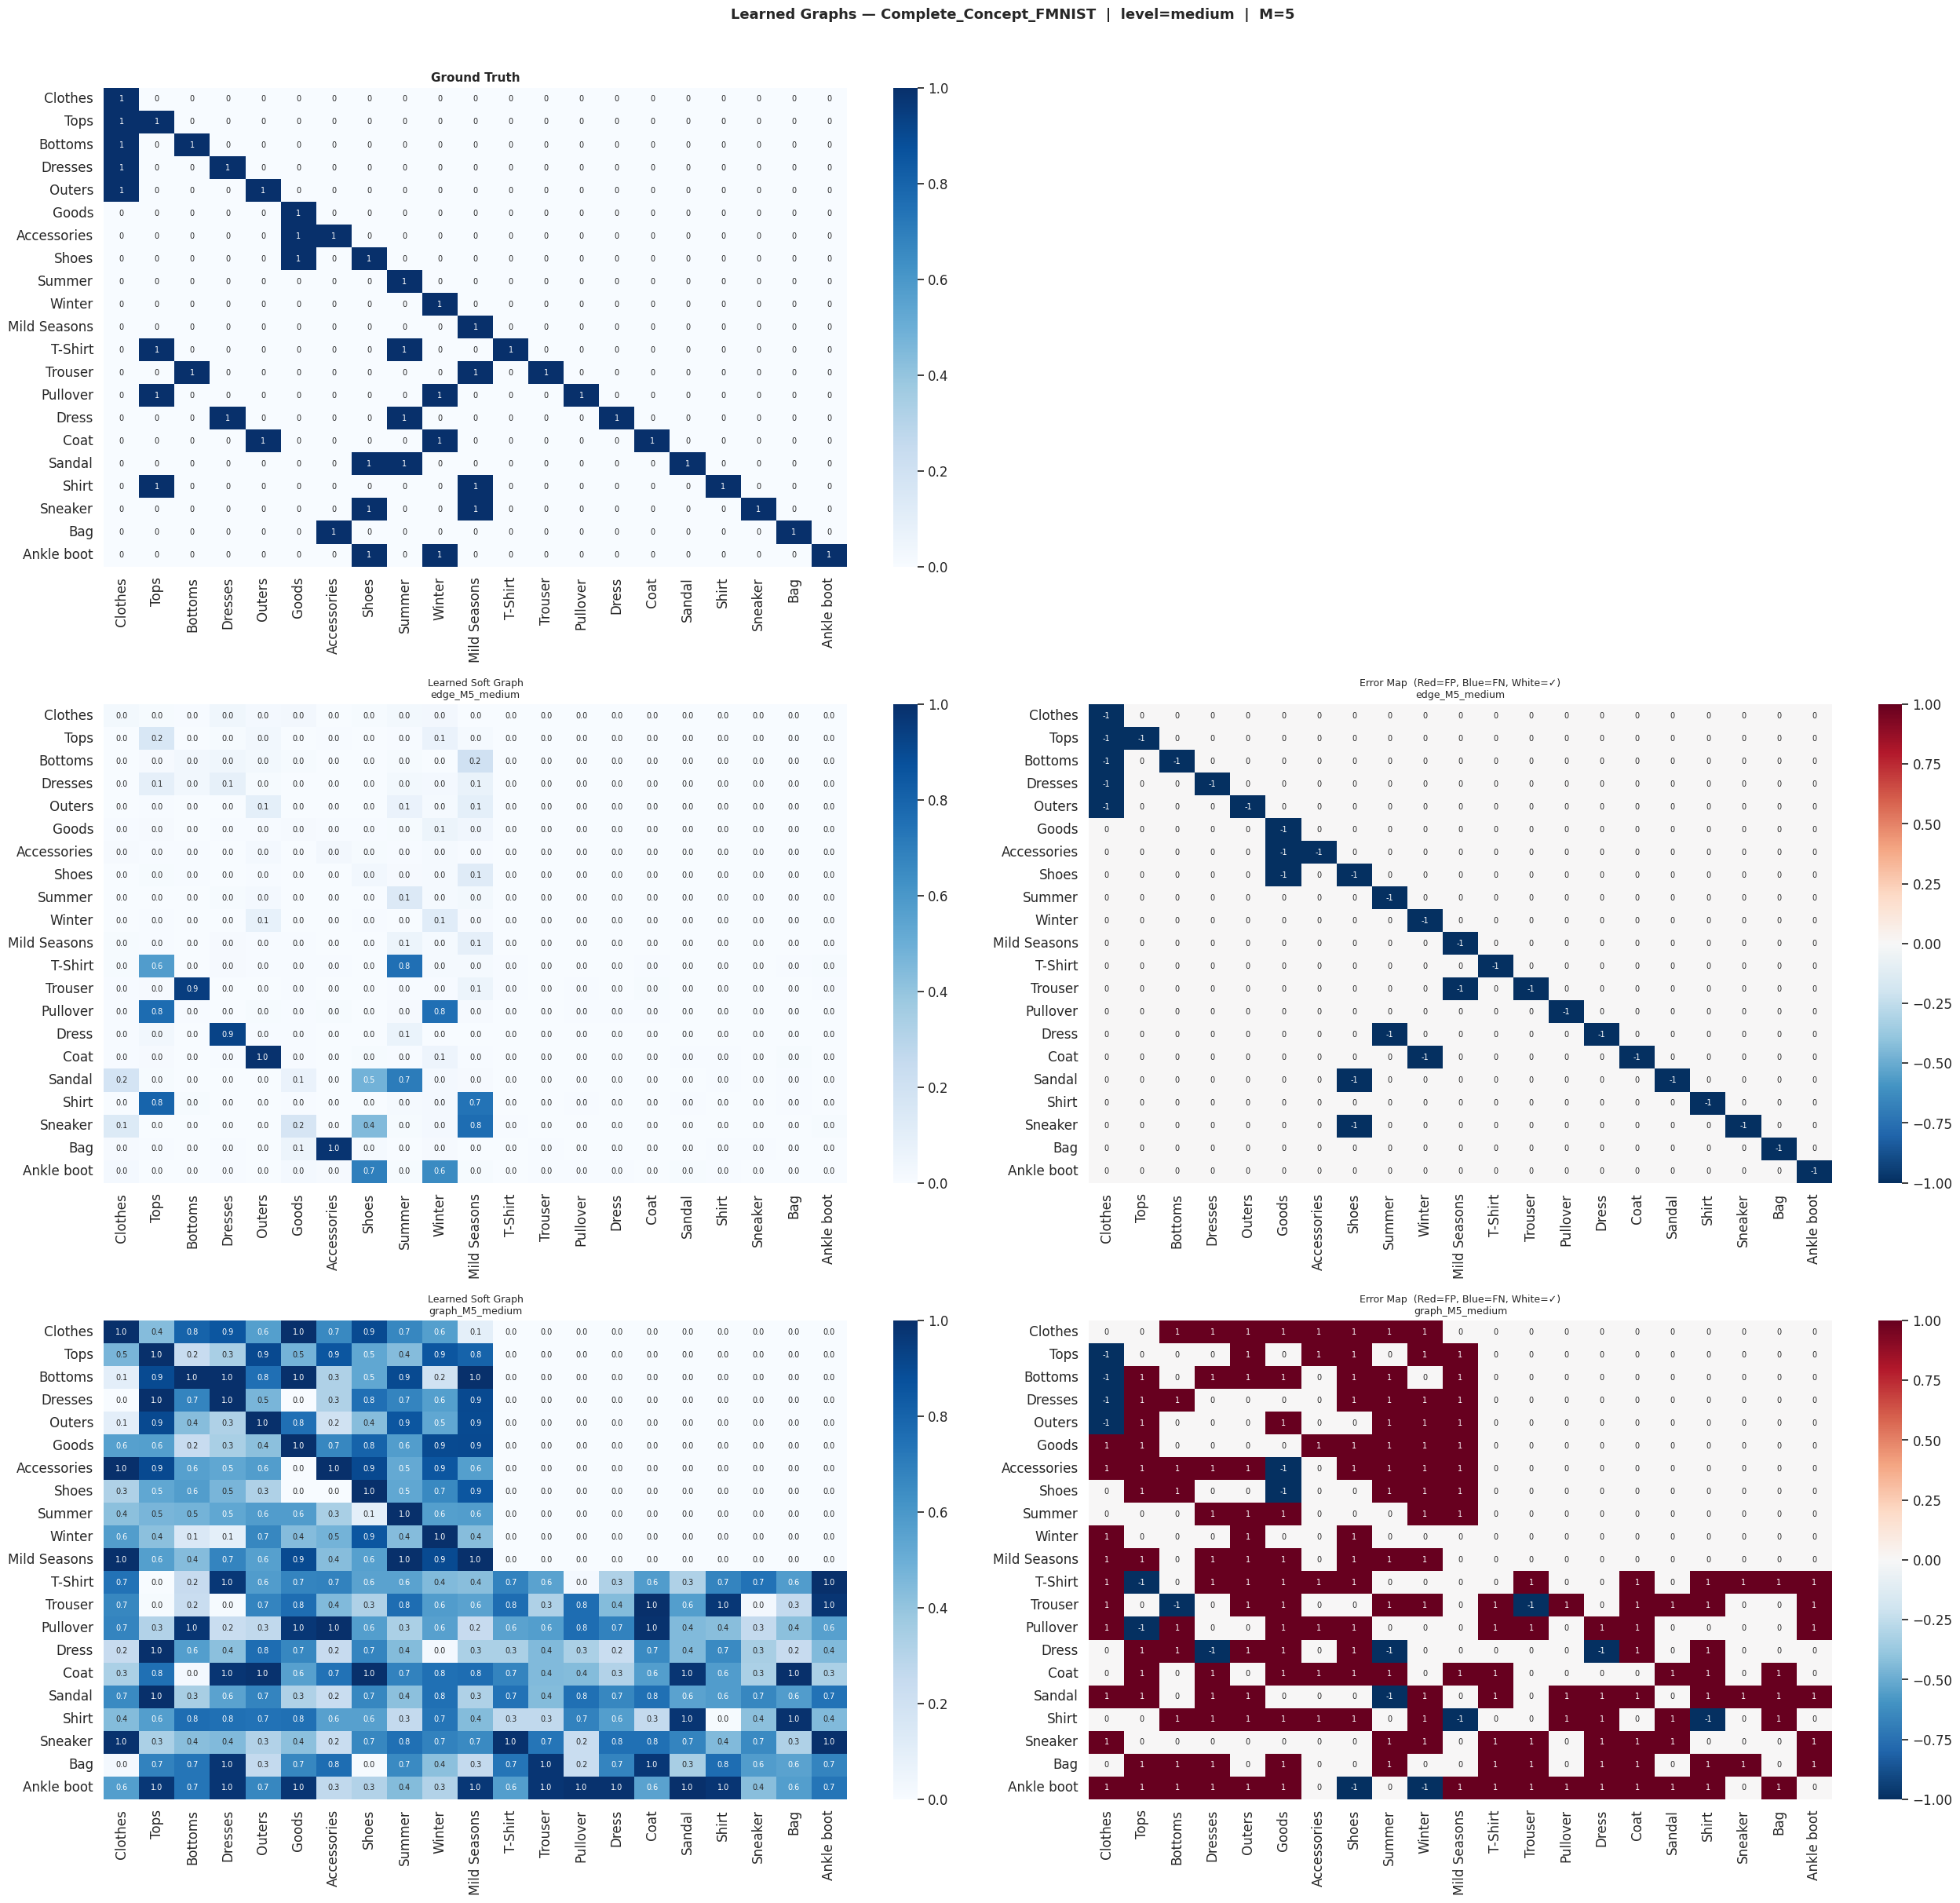

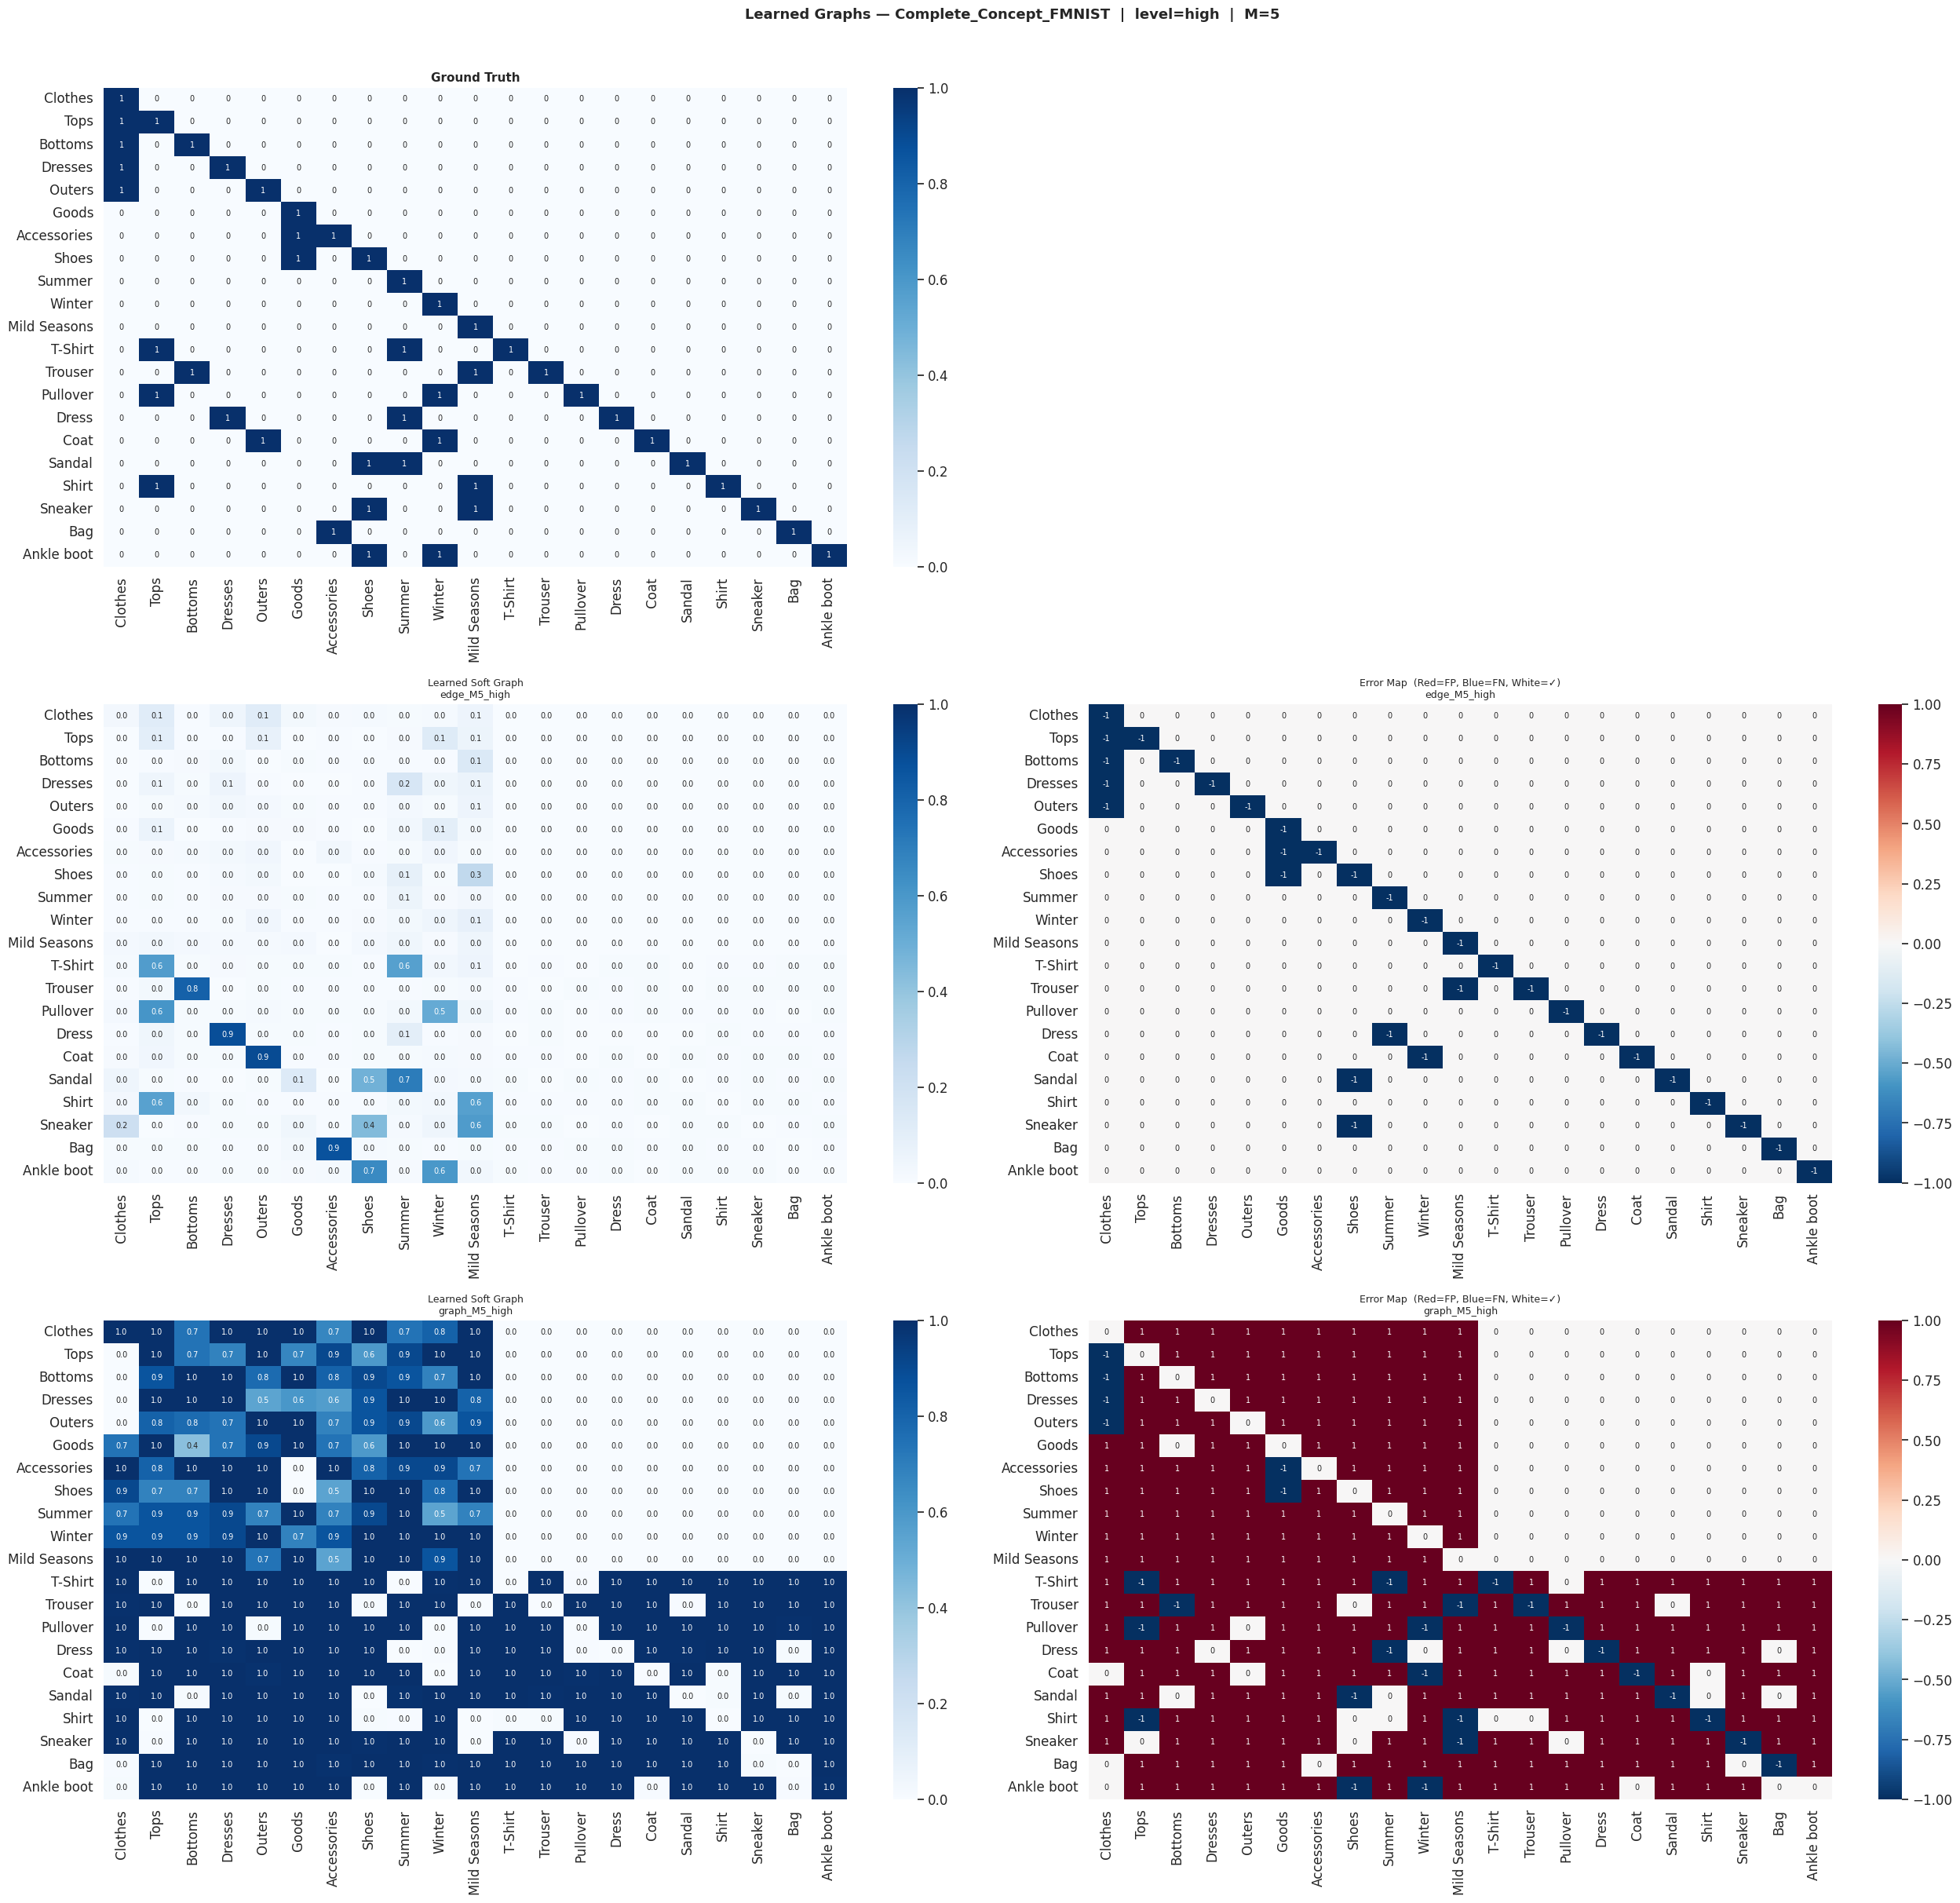

In [9]:
def plot_graphs_for_dataset(dataset: str, level: str = "high", m_val: int = 5):
    """
    One figure per dataset / level / M:
      Row 0        :  Ground Truth (left)  |  (right hidden)
      Row 1, 2, …  :  Learned Soft Graph   |  Error Map   ← one row per method
    """
    mcream_dir = EXPERIMENTS_ROOT / dataset / "train_cbm" / "mCREAM"
    if not mcream_dir.exists():
        print(f"No mCREAM dir for {dataset}")
        return

    # ── collect (label, soft_df, gt_df) per method ──────────────────────────
    entries = []
    gt_shared = None

    for exp_dir in sorted(mcream_dir.iterdir()):
        if not exp_dir.is_dir():
            continue
        name_lower = exp_dir.name.lower()
        if level.lower() not in name_lower:
            continue
        if f"m{m_val}" not in name_lower.replace("_", ""):
            continue

        for seed_dir in sorted(exp_dir.glob("seed_*/lightning_logs/version_*")):
            soft_csv = seed_dir / "learned_graphs" / "aggregated_dag_soft.csv"
            gt_csv   = seed_dir / "learned_graphs" / "ground_truth_dag.csv"
            if not soft_csv.exists():
                continue
            soft = pd.read_csv(soft_csv, index_col=0).astype(float)
            gt   = pd.read_csv(gt_csv, index_col=0).astype(float) if gt_csv.exists() else None
            if gt is not None and gt_shared is None:
                gt_shared = gt
            entries.append((exp_dir.name, soft, gt))
            break   # one seed per method

    if not entries:
        print(f"No data for {dataset} | level={level} | M={m_val}")
        return

    n_methods = len(entries)
    n_rows    = 1 + n_methods          # row 0 = GT, rows 1..n = methods
    fig, axes = plt.subplots(n_rows, 2, figsize=(26, 8 + 8 * n_methods))
    if n_rows == 1:
        axes = axes[np.newaxis, :]     # ensure always 2-D

    fig.suptitle(
        f"Learned Graphs — {dataset}  |  level={level}  |  M={m_val}",
        fontsize=13, fontweight="bold", y=1.01
    )

    # ── Row 0: Ground Truth (once, shared) ──────────────────────────────────
    ax_gt = axes[0, 0]
    if gt_shared is not None:
        sns.heatmap(gt_shared.values, ax=ax_gt, vmin=0, vmax=1,
                    cmap="Blues", annot=True, fmt=".0f",
                    xticklabels=gt_shared.columns, yticklabels=gt_shared.index,
                    annot_kws={"size": 7})
        ax_gt.set_title("Ground Truth", fontsize=11, fontweight="bold")
    else:
        ax_gt.text(0.5, 0.5, "No ground truth", ha="center", va="center",
                   transform=ax_gt.transAxes)
    axes[0, 1].set_visible(False)      # right cell of GT row unused

    # ── Rows 1+: one row per method ─────────────────────────────────────────
    for row_i, (label, soft, gt) in enumerate(entries, start=1):
        ax_soft  = axes[row_i, 0]
        ax_error = axes[row_i, 1]

        # Left — Learned Soft Graph
        sns.heatmap(soft.values, ax=ax_soft, vmin=0, vmax=1,
                    cmap="Blues", annot=True, fmt=".1f",
                    xticklabels=soft.columns, yticklabels=soft.index,
                    annot_kws={"size": 7})
        ax_soft.set_title(f"Learned Soft Graph\n{label}", fontsize=9)

        # Right — Error Map
        if gt is not None:
            lb  = (soft.values > 0.5).astype(float)
            gtb = gt.values
            err = np.zeros_like(lb)
            err[(lb == 1) & (gtb == 0)] =  1   # FP → red
            err[(lb == 0) & (gtb == 1)] = -1   # FN → blue
            sns.heatmap(err, ax=ax_error, vmin=-1, vmax=1,
                        cmap="RdBu_r", center=0, annot=True, fmt=".0f",
                        xticklabels=soft.columns, yticklabels=soft.index,
                        annot_kws={"size": 7})
            ax_error.set_title(f"Error Map  (Red=FP, Blue=FN, White=✓)\n{label}", fontsize=9)
        else:
            ax_error.set_visible(False)

    plt.tight_layout()
    plt.savefig(f"learned_graph_{dataset}_{level}_M{m_val}.png", dpi=150, bbox_inches="tight")
    plt.show()


# ── Run for all datasets — graph_M5_high by default ─────────────────────────
# if EXPERIMENTS_ROOT.exists():
#     for ds in DATASETS:
#         plot_graphs_for_dataset(ds, level="high", m_val=5)

# Uncomment to sweep all levels:
for ds in DATASETS:
    for lv in ["low", "medium", "high",]:
        plot_graphs_for_dataset(ds, level=lv, m_val=5)

## 11. Exogenous Correlation Analysis

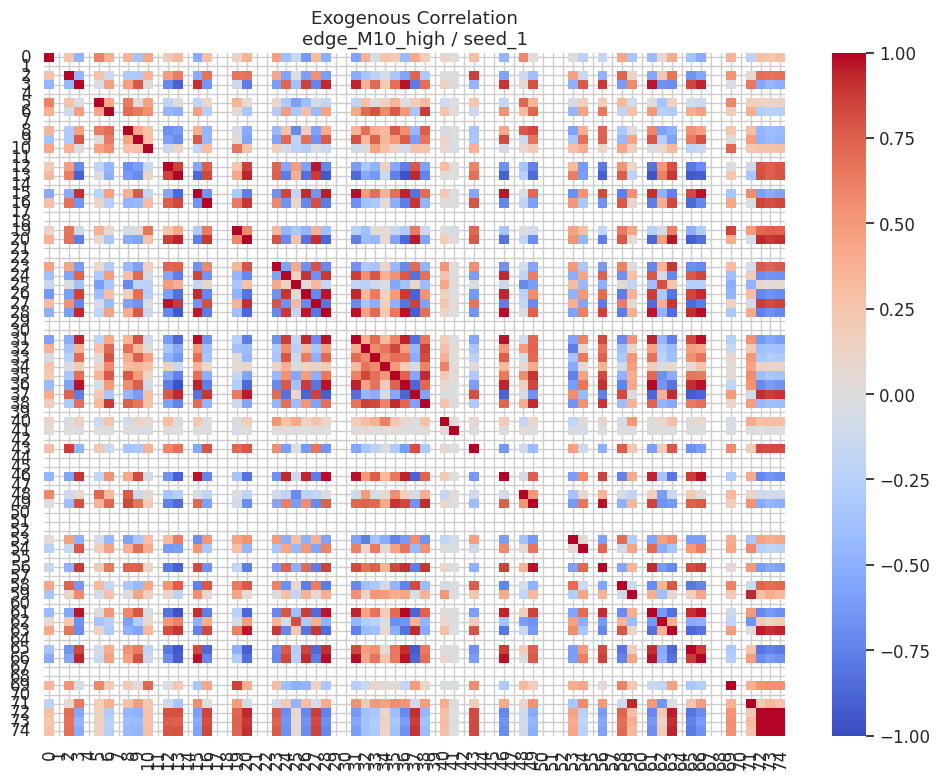

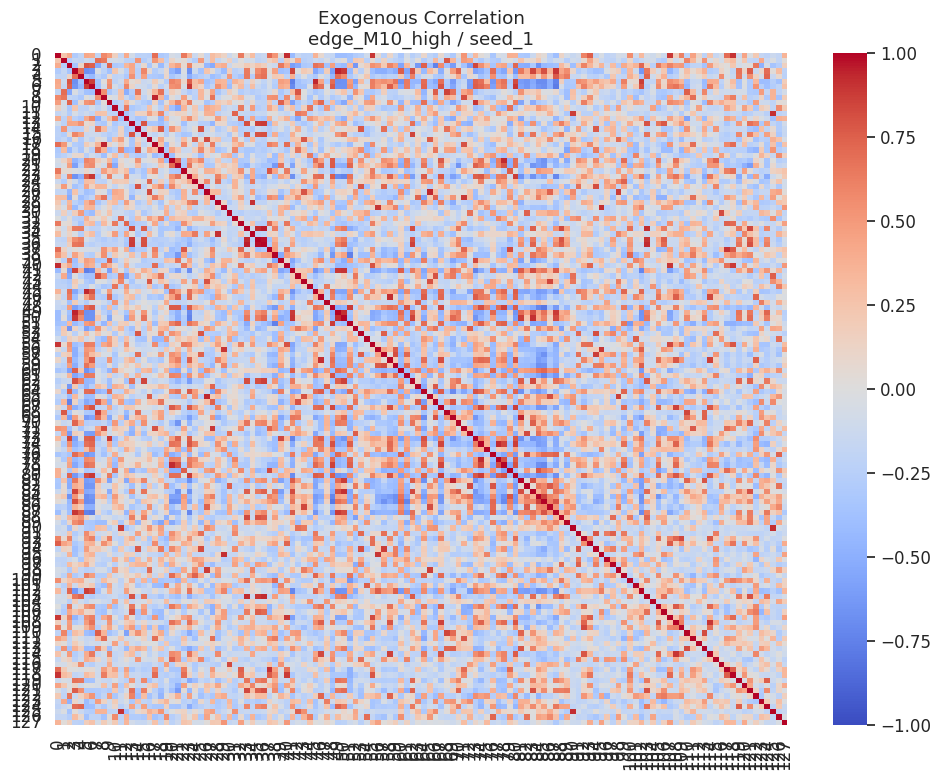

In [18]:
def load_and_plot_correlation(exp_path: Path, title=""):
    """Load and plot the exogenous correlation matrix."""
    corr_csv = exp_path / "correlation_analysis" / "exogenous_correlation_matrix.csv"
    abs_corr_csv = exp_path / "correlation_analysis" / "exogenous_abs_correlation_matrix.csv"
    
    if not corr_csv.exists():
        return
    
    corr = pd.read_csv(corr_csv, index_col=0)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr.values.astype(float), ax=ax, vmin=-1, vmax=1, 
                cmap="coolwarm", center=0,
                xticklabels=corr.columns, yticklabels=corr.index)
    ax.set_title(f"Exogenous Correlation\n{title}")
    plt.tight_layout()
    plt.show()

# Example
if EXPERIMENTS_ROOT.exists():
    for dataset in DATASETS:
        mcream_dir = EXPERIMENTS_ROOT / dataset / "train_cbm" / "mCREAM"
        if not mcream_dir.exists():
            continue
        for exp_dir in sorted(mcream_dir.iterdir()):
            for seed_dir in sorted(exp_dir.glob("seed_*/lightning_logs/version_*")):
                if (seed_dir / "correlation_analysis" / "exogenous_correlation_matrix.csv").exists():
                    load_and_plot_correlation(seed_dir, f"{exp_dir.name} / {seed_dir.parent.parent.name}")
                    break
            else:
                continue
            break

## 12. Expert Weights (Graph-level only)

In [19]:
if len(results_df) > 0:
    # Expert weights columns: expert_weights_u2c, expert_weights_c2y
    weight_cols = [c for c in results_df.columns if "expert_weights" in c]
    if weight_cols:
        graph_only = results_df[results_df["method"] == "graph"].copy()
        if not graph_only.empty:
            print("Expert Weights (Graph-level aggregation):")
            print("="*60)
            for _, row in graph_only.iterrows():
                print(f"  {row['experiment_name']} (seed={row['seed']}):")
                for col in weight_cols:
                    if pd.notna(row.get(col)):
                        print(f"    {col}: {row[col]}")
                print()

Expert Weights (Graph-level aggregation):
  graph_M10_high (seed=1):
    expert_weights_u2c: [0.06083694100379944, 0.05239539593458176, 0.0672527477145195, 0.10698281228542328, 0.15813857316970825, 0.10268483310937881, 0.0936092734336853, 0.08077187091112137, 0.10215101391077042, 0.17517657577991486]
    expert_weights_c2y: [0.433018296957016, 0.0004332370008341968, 0.433018296957016, 0.0004332370008341968, 0.0004332370008341968, 0.0001360200549243018, 0.00026536741643212736, 0.13103912770748138, 0.0003369388577993959, 0.0008862882386893034]

  graph_M10_high (seed=1):
    expert_weights_u2c: [0.05862388014793396, 0.05464201793074608, 0.0656590610742569, 0.10740455985069275, 0.15337379276752472, 0.10679996758699417, 0.0907713994383812, 0.0747123658657074, 0.09737326204776764, 0.1906396746635437]
    expert_weights_c2y: [0.4328876733779907, 0.0004373173287604004, 0.4328876733779907, 0.0004373173287604004, 0.0004373173287604004, 0.00013745835167355835, 0.000268025032710284, 0.13125728070

## 13. Timing & Efficiency

In [20]:
if len(results_df) > 0:
    timing_cols = ["train_val_time", "test_time", "num_trainable_parameters", 
                   "num_effective_parameters", "disconnected_weights", "peak_gpu_memory_mb"]
    available = [c for c in timing_cols if c in results_df.columns]
    
    if available:
        timing_summary = make_summary_table(results_df, available)
        print("TIMING & EFFICIENCY")
        print("="*80)
        display(timing_summary)

TIMING & EFFICIENCY


n_seeds  \
dataset                 method       M  disagreement_level            
CelebA                  edge         5  high                      5   
                                        low                       5   
                                        medium                    5   
                                        structured_bias           3   
                                     10 high                      9   
                                        low                       9   
                                        medium                   10   
                                        structured_bias          10   
                        graph        5  high                      5   
                                        low                       5   
                                        medium                    5   
                                        structured_bias           5   
                                     10 high                     10   
                                        low                       9   
                                        medium                   10   
                                        structured_bias          10   
                        intersection 5  medium                    1   
                                     10 high                      6   
                                        low                       6   
                                        medium                    6   
                                        structured_bias           6   
                        majority     10 high                      5   
                                        low                       5   
                                        medium                    5   
                                        structured_bias           5   
                        union        10 high                      5   
                                        low                       5   
                                        medium                    4   
                                        structured_bias           4   
Complete_Concept_FMNIST edge         5  high                      5   
                                        low                       5   
                                        medium                    5   
                                        structured_bias           5   
                                     10 high                     10   
                                        medium                   10   
                                        structured_bias          10   
                        graph        5  high                      5   
                                        low                       5   
                                        medium                    5   
                                        structured_bias           5   
                                     10 high                     10   
                                        medium                   10   
                                        structured_bias          10   
                        intersection 10 high                      5   
                                        low                       5   
                                        medium                    5   
                                        structured_bias           5   
                        majority     10 high                      5   
                                        medium                    5   
                                        structured_bias           5   
                        union        10 high                      5   
                                        low                       5   
                                        medium                    5   
                                        structured_bias           5   

                                                                train_val_time  \
d

## 14. Export Final Summary Table (LaTeX-ready)

In [21]:
if len(results_df) > 0:
    # Create a compact table for the paper
    key_metrics = ["test_task_accuracy", "test_concept_accuracy", "CCI", 
                   "u2c_f1", "c2y_f1", "concept_leakage"]
    available_key = [c for c in key_metrics if c in results_df.columns]
    
    # Aggregate: mean ± std as numeric
    group_cols = ["dataset", "method", "M", "disagreement_level"]
    agg = results_df.groupby(group_cols)[available_key].agg(["mean", "std"]).round(4)
    
    # Save to CSV
    agg.to_csv("mcream_summary_table.csv")
    print("Saved summary to mcream_summary_table.csv")
    
    # Display
    display(agg)

Saved summary to mcream_summary_table.csv


test_task_accuracy  \
                                                                         mean   
dataset                 method       M  disagreement_level                      
CelebA                  edge         5  high                           0.7800   
                                        low                            0.7894   
                                        medium                         0.7866   
                                        structured_bias                0.7886   
                                     10 high                           0.7832   
                                        low                            0.7937   
                                        medium                         0.7927   
                                        structured_bias                0.7942   
                        graph        5  high                           0.7834   
                                        low                            0.7927   
                                        medium                         0.7946   
                                        structured_bias                0.7890   
                                     10 high                           0.7803   
                                        low                            0.7881   
                                        medium                         0.7893   
                                        structured_bias                0.7895   
                        intersection 5  medium                         0.7769   
                                     10 high                           0.7945   
                                        low                            0.7841   
                                        medium                         0.7944   
                                        structured_bias                0.7944   
                        majority     10 high                           0.8000   
                                        low                            0.7897   
                                        medium                         0.7785   
                                        structured_bias                0.7872   
                        union        10 high                           0.7845   
                                        low                            0.7913   
                                        medium                         0.7931   
                                        structured_bias                0.7933   
Complete_Concept_FMNIST edge         5  high                           0.9263   
                                        low                            0.9259   
                                        medium                         0.9267   
                                        structured_bias                0.9260   
                                     10 high                           0.9261   
                                        medium                         0.9264   
                                        structured_bias                0.9256   
                        graph        5  high                           0.9251   
                                        low                            0.9249   
                                        medium                         0.9243   
                                        structured_bias                0.9255   
                                     10 high                           0.9252   
                                        medium                         0.9257   
                                        structured_bias                0.9252   
                        intersection 10 high                           0.9228   
                                        low                            0.9261   
                                        medium                         0.9261   
                                        structured_bias                0.9261   
         

## 15. Quick Sanity Checks

In [ ]:
if len(results_df) > 0:
    print("SANITY CHECKS")
    print("=" * 60)
    
    # Check: edge/graph should beat baselines on graph recovery
    if "u2c_f1" in results_df.columns:
        for dataset in results_df["dataset"].unique():
            ds = results_df[results_df["dataset"] == dataset]
            for level in ds["disagreement_level"].unique():
                lv = ds[ds["disagreement_level"] == level]
                baselines_f1 = lv[lv["method"].isin(["intersection", "majority", "union"])]["u2c_f1"].mean()
                learnable_f1 = lv[lv["method"].isin(["edge", "graph", "graph_mlp"])]["u2c_f1"].mean()
                status = "✓" if learnable_f1 >= baselines_f1 else "✗"
                print(f"  {status} {dataset}/{level}: learnable F1={learnable_f1:.3f} vs baselines F1={baselines_f1:.3f}")
    
    # Check: CCI should be > 0.5 (concepts dominate)
    if "CCI" in results_df.columns:
        mean_cci = results_df["CCI"].dropna().mean()
        print(f"\n  Mean CCI across all experiments: {mean_cci:.3f} {'✓ > 0.5' if mean_cci > 0.5 else '✗ < 0.5'}")
    
    # Check: concept leakage should be near 0
    if "concept_leakage" in results_df.columns:
        mean_leak = results_df["concept_leakage"].dropna().mean()
        print(f"  Mean leakage: {mean_leak:.4f} {'✓ low' if mean_leak < 0.05 else '⚠ check'}")
    
    # Missing results check
    print(f"\n  Total experiments: {len(results_df)}")
    expected = len(DATASETS) * len(METHODS) * len(M_VALUES) * len(DISAGREEMENT_LEVELS) * 5  # 5 seeds
    print(f"  Expected (full grid): {expected}")
    print(f"  Coverage: {len(results_df)/expected*100:.0f}%")

SANITY CHECKS
  ✗ CelebA/high: learnable F1=0.131 vs baselines F1=0.408
  ✗ CelebA/low: learnable F1=0.380 vs baselines F1=0.737
  ✗ CelebA/medium: learnable F1=0.168 vs baselines F1=0.537
  ✗ CelebA/structured_bias: learnable F1=0.303 vs baselines F1=0.699
  ✗ Complete_Concept_FMNIST/high: learnable F1=0.084 vs baselines F1=0.278
  ✗ Complete_Concept_FMNIST/medium: learnable F1=0.113 vs baselines F1=0.422
  ✗ Complete_Concept_FMNIST/structured_bias: learnable F1=0.153 vs baselines F1=0.574
  ✗ Complete_Concept_FMNIST/low: learnable F1=0.296 vs baselines F1=0.521

  Mean CCI across all experiments: 0.801 ✓ > 0.5
  Mean leakage: 0.0000 ✓ low

  Total experiments: 333
  Expected (full grid): 400
  Coverage: 83%
